# AQA — Air Quality Analysis Pipeline
### European Environment Agency · ERA5 Meteorology · Sentinel-5P

This notebook implements the full AQA pipeline using **EEA** ground-level air quality data,
ERA5 reanalysis meteorology, and Sentinel-5P satellite observations.
It is designed to work for **any European country or bounding box** with minimal setup.

**Pipeline overview**

| Step | Description |
|------|-------------|
| 1 | Configuration: spatial mode, pollutants, date range, dataset |
| 2 | EEA station metadata: filter, clean, map |
| 3 | EEA measurements download (Parquet via async API) |
| 4a | Unzip & list downloaded Parquet files |
| 4b | Build wide dataset (one column per pollutant) |
| 4c | Time-window summary (prev/curr window means) |
| 5 | Draw analysis bbox on interactive map |
| 5b | Clip sensors to bbox |
| 6 | Build spatial interpolation grid |
| 7 | ERA5 download from CDS API |
| 7b | Merge ERA5 files & convert units |
| 8 | Bilinear interpolation of ERA5 onto sensor grid |
| 8b | ERA5 time-window means |
| 9 | Join EEA sensors + ERA5 (nearest-neighbour) |
| 10 | Sentinel-5P column extraction via Google Earth Engine |
| 11 | Rename, visualise, export |
| 12 | Export final cleaned CSV |

---
> **How to use:** Edit the **Step 1 configuration widget**, click *Save Configuration*, then run all subsequent cells in order.

## Libraries & PROJ Fix

All dependencies are imported here. If you encounter a `CRSError: Invalid projection: EPSG:4326` error,
uncomment the PROJ block — it forces `pyproj` to look in the correct Conda environment directory
for its projection database.

In [1]:
import os, glob, zipfile, shutil, re, unicodedata, time
import numpy as np
import pandas as pd
import requests
import geopandas as gpd
import xarray as xr
import folium
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime, timedelta
from shapely.geometry import box, Point
from scipy.spatial import distance_matrix
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import ee
import geemap
import cdsapi
import warnings
warnings.filterwarnings('ignore')

# PROJ fix — uncomment if CRSError appears
import pyproj
proj_path = r'C:\Users\Administrador\anaconda3\envs\cmcc_env\Library\share\proj'
os.environ['PROJ_LIB'] = proj_path
pyproj.datadir.set_data_dir(proj_path)
print('PROJ path set:', pyproj.datadir.get_data_dir())

# Google Earth Engine authentication
ee.Authenticate()
ee.Initialize(project='ee-saudisis')  # Replace with your GEE project ID

print('Libraries loaded successfully.')

C:\Users\Administrador\anaconda3\envs\cmcc_env\lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


PROJ path set: C:\Users\Administrador\anaconda3\envs\cmcc_env\Library\share\proj
Libraries loaded successfully.


## Step 1 - Configuration

Fill in all parameters below and click **Save Configuration**.
All subsequent steps read from the `cfg` dictionary — you should not need to touch any other cell.

### EEA Dataset reference

The EEA Download Service provides the following time series:

| Code | Name | Period | Description |
|------|------|--------|-------------|
| **E1a** | Verified data | 2013–2024 | Reported annually by countries by 30 September |
| **E2a** | Up-To-Date (UTD) | 2024+ | Transmitted continuously, not yet verified |
| -- | Historical Airbase | 2002–2012 | Pre Air Quality Directive 2008/50/EC (not in this pipeline) |

> **Rule of thumb:** use E1a for past analysis (≤ 2023), E2a for near-real-time (2024+).  
> `auto` selects E1a for years ≤ 2023 and E2a for 2024+.

> **Note on aggregation:** If you choose *day*, *month*, or *year* aggregation, the downloaded
> Parquet files will already contain pre-aggregated values. The prev/curr time windows you define
> will then have limited practical use because there won't be enough temporal resolution to
> distinguish the Sentinel overpass window. Use *hourly* aggregation for Sentinel-5P integration.  
> More information: https://dd.eionet.europa.eu/vocabulary/aq/primaryObservation

### Time windows

Each day is split into two windows bracketing the Sentinel-5P overpass:
- **Previous** — hours before the overpass (may span midnight).
- **Current** — the overpass window itself.

Find the sensing time at [Copernicus Browser](https://browser.dataspace.copernicus.eu/):
*Find products for current view* → *Product info* → *Sensing time*.

> **Timezone note:** All time window inputs are interpreted as **UTC**.
> If the satellite overpass time is given in local time (e.g. CET = UTC+1), subtract the offset before entering it here.

In [2]:
# Global configuration widget — run once per session.
cfg = {}

# Load country list from the pre-processed station metadata
stations_path = r'C:\Users\Administrador\Downloads\output\eea_sensor_meta.csv'
_tmp = pd.read_csv(stations_path, encoding='utf-8', usecols=['Country'],
                   low_memory=False, on_bad_lines='skip')
country_options = sorted(_tmp['Country'].dropna().astype(str).str.strip().unique())

_S  = {'description_width': '120px'}
_LW = widgets.Layout(width='230px')

# Spatial mode
mode_w = widgets.RadioButtons(
    options=[('Country filter', 'country'), ('Bounding box', 'bbox')],
    value='country', description='Spatial mode:', style=_S,
    layout=widgets.Layout(width='270px')
)
country_w = widgets.Dropdown(
    options=country_options,
    value='Italy' if 'Italy' in country_options else country_options[0],
    description='Country:', style=_S, layout=_LW
)

# Bounding box (WGS-84 decimal degrees)
lon_min_w = widgets.FloatText(value=8.9,  description='Min lon:', style=_S, layout=_LW)
lat_min_w = widgets.FloatText(value=45.3, description='Min lat:', style=_S, layout=_LW)
lon_max_w = widgets.FloatText(value=9.6,  description='Max lon:', style=_S, layout=_LW)
lat_max_w = widgets.FloatText(value=45.7, description='Max lat:', style=_S, layout=_LW)

# Time windows (HH:MM, UTC)
prev_start_w = widgets.Text(value='15:01', description='Prev start:', style=_S, layout=_LW)
prev_end_w   = widgets.Text(value='11:59', description='Prev end:',   style=_S, layout=_LW)
curr_start_w = widgets.Text(value='12:00', description='Curr start:', style=_S, layout=_LW)
curr_end_w   = widgets.Text(value='15:00', description='Curr end:',   style=_S, layout=_LW)

# Pollutant selection
_poll_options = ['SO2', 'CO', 'NO2', 'NOX as NO2']
_poll_checks  = {p: widgets.Checkbox(
                     value=(p in ['SO2', 'CO', 'NO2']),
                     description=p,
                     style={'description_width': '0px'},
                     layout=widgets.Layout(width='130px')
                 )
                 for p in _poll_options}

# Date range
start_date_w = widgets.DatePicker(description='Start date:', style=_S, layout=_LW)
end_date_w   = widgets.DatePicker(description='End date:',   style=_S, layout=_LW)

# Aggregation and dataset
agg_w = widgets.Dropdown(
    options=[
        ('Hourly',  'hour'),
        ('Daily',   'day'),
        ('Monthly', 'month'),
        ('Yearly',  'year'),
    ],
    value='hour',
    description='Aggregation:', style=_S, layout=_LW
)
dataset_w = widgets.RadioButtons(
    options=[
        ('auto  (E1a <= 2022 | E2a >= 2023)', 'auto'),
        ('E2a  -- Up-To-Date / UTD (2023+)',   1),
        ('E1a  -- Verified data (2013-2022)',  2),
    ],
    value='auto', description='Dataset:', style=_S,
    layout=widgets.Layout(width='350px')
)
email_w = widgets.Text(
    value='your.email@example.com',
    description='Email:', style=_S, layout=widgets.Layout(width='280px')
)

btn     = widgets.Button(description='Save Configuration', button_style='success',
                         layout=widgets.Layout(width='220px', margin='16px 0 0 0'))
out_cfg = widgets.Output()

def _build_aoi(bbox):
    minx, miny, maxx, maxy = bbox
    aoi = gpd.GeoDataFrame({'id': [1]}, geometry=[box(minx, miny, maxx, maxy)], crs='EPSG:4326')
    return aoi, aoi.to_crs('EPSG:32632')

def _dataset_label(did):
    return {1: 'E2a (up-to-date, 2023+)', 2: 'E1a (verified, 2013-2022)'}.get(did, str(did))  # docs: 1=E2a, 2=E1a

def on_save(_):
    global cfg
    with out_cfg:
        clear_output()
        start_dt = pd.to_datetime(start_date_w.value) if start_date_w.value else None
        end_dt   = pd.to_datetime(end_date_w.value)   if end_date_w.value   else None
        year     = start_dt.year if start_dt is not None else None

        if dataset_w.value == 'auto':
            dataset_id = 2 if (year is None or year <= 2022) else 1  # docs: 1=E2a(2023+), 2=E1a(2013-2022)
        else:
            dataset_id = int(dataset_w.value)

        selected_pollutants = [p for p, cb in _poll_checks.items() if cb.value]
        if not selected_pollutants:
            print('Please select at least one pollutant.')
            return

        if start_dt and end_dt and start_dt > end_dt:
            print('Error: Start date must be before or equal to End date.')
            return

        bbox = ([lon_min_w.value, lat_min_w.value, lon_max_w.value, lat_max_w.value]
                if mode_w.value == 'bbox' else None)

        cfg = {
            'mode':            mode_w.value,
            'country':         country_w.value.strip() if mode_w.value == 'country' else None,
            'bbox':            bbox,
            'pollutants':      selected_pollutants,
            'start_date':      start_dt,
            'end_date':        end_dt,
            'aggregationType': agg_w.value,
            'time_windows': {
                'prev': (prev_start_w.value, prev_end_w.value),
                'curr': (curr_start_w.value, curr_end_w.value),
            },
            'crs_gee':  'EPSG:4326',
            'crs_grid': 'EPSG:32632',
            'sentinel_scale_km': 5.5,
            'api': {
                'apiUrl':          'https://eeadmz1-downloads-api-appservice.azurewebsites.net/',
                'endpoint':        'ParquetFile/async',
                'dataset':         dataset_id,
                'email':           email_w.value.strip(),
                'min_zip_bytes':   10_000,
                'poll_seconds':    20,
                'timeout_seconds': 3600,
            },
            'paths': {
                'thesis_dir':    r'C:\Users\Administrador\Downloads\Thesis',
                'stations_csv':  stations_path,
                'clean_csv':     r'C:\Users\Administrador\Downloads\Thesis\stations_clean.csv',
                'clean_parquet': r'C:\Users\Administrador\Downloads\Thesis\stations_clean.parquet',
                'zip_name':      'EEA_download.zip',
                'extract_dir':   r'C:\Users\Administrador\Downloads\Thesis\EEA_unzipped',
            },
        }

        if cfg['bbox']:
            cfg['aoi'], cfg['aoi_utm'] = _build_aoi(cfg['bbox'])
            cfg['aoi_gee'] = ee.Geometry.Rectangle(cfg['bbox'])
        else:
            cfg['aoi'] = cfg['aoi_utm'] = cfg['aoi_gee'] = None

        cfg['dates'] = pd.date_range(start_dt, end_dt, freq='D') if (start_dt and end_dt) else None

        W = 56
        print('-' * W)
        print('  Configuration saved')
        print('-' * W)
        print(f"  Spatial mode  : {cfg['mode']}")
        if cfg['mode'] == 'country':
            print(f"  Country       : {cfg['country']}")
        else:
            print(f"  Bounding box  : {cfg['bbox']}")
        print(f"  Pollutants    : {', '.join(cfg['pollutants'])}")
        print(f"  Date range    : {cfg['start_date']} -> {cfg['end_date']}")
        print(f"  Aggregation   : {cfg['aggregationType']}")
        print(f"  Dataset       : {_dataset_label(cfg['api']['dataset'])}")
        print(f"  Prev window   : {cfg['time_windows']['prev'][0]} -> {cfg['time_windows']['prev'][1]}")
        print(f"  Curr window   : {cfg['time_windows']['curr'][0]} -> {cfg['time_windows']['curr'][1]}")
        print('-' * W)
        print('  Next: run Step 2 to load station metadata.')

btn.on_click(on_save)

# Layout
col_spatial = widgets.VBox([
    widgets.HTML('<b>Spatial selection</b>'), mode_w, country_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_bbox = widgets.VBox([
    widgets.HTML('<b>Bounding box (WGS-84)</b>'),
    lon_min_w, lat_min_w, lon_max_w, lat_max_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_time = widgets.VBox([
    widgets.HTML('<b>Time windows (HH:MM, UTC)</b>'),
    prev_start_w, prev_end_w, curr_start_w, curr_end_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_right = widgets.VBox([
    widgets.HTML('<b>Pollutants</b>'),
    widgets.HBox(
        list(_poll_checks.values()),
        layout=widgets.Layout(flex_flow='row wrap', width='500px')
    ),
    widgets.HTML('<b>Date range</b>'),
    start_date_w, end_date_w,
    widgets.HTML('<b>Aggregation & Dataset</b>'),
    agg_w, dataset_w,
    widgets.HTML('<b>Email (for EEA API)</b>'),
    email_w,
])

display(widgets.HBox([col_spatial, col_bbox, col_time, col_right]), btn, out_cfg)

Button(button_style='success', description='Save Configuration', layout=Layout(margin='16px 0 0 0', width='220…

Output()

## Step 2 - EEA Station Metadata

Reads the pre-processed `eea_sensor_meta.csv` (produced by the companion *EEA Metadata Clean* notebook)
and applies the spatial filter from `cfg`.

**What happens here:**
1. Coordinates are coerced to numeric; rows with missing coordinates are dropped.
2. Pollutant name variants (e.g. `NOx as NO2` → `NOX as NO2`) are normalised for consistency.
3. The dataset is filtered to the pollutants and spatial extent selected in Step 1.
4. An aggregated table is built: one row per physical station (`sensor_uid`) and one per sensor × pollutant pair.

The original CSV is available at:
https://discomap.eea.europa.eu/App/AQViewer/index.html?fqn=Airquality_Dissem.b2g.measurements

In [8]:
'''
Read and clean the EEA stations metadata CSV (pre-processed format).
The file already has one row per sensor x pollutant with a pre-built sensor_uid.
We normalise pollutant names, filter to selected pollutants, apply spatial filter,
then aggregate to unique physical stations.
'''
W = 56

print('-' * W)
print('  Step 2 - Loading EEA station metadata')
print(f"  Source     : {cfg['paths']['stations_csv']}")
print(f"  Pollutants : {cfg['pollutants']}")
print('-' * W)

meta_path = Path(cfg['paths']['stations_csv'])
df_meta   = pd.read_csv(meta_path, encoding='utf-8', low_memory=False, on_bad_lines='skip')
total_raw = len(df_meta)
print(f'\n  Raw rows loaded            : {total_raw:,}')

# Coerce coordinates; drop rows without valid position
df_meta['Longitude'] = pd.to_numeric(df_meta['Longitude'], errors='coerce')
df_meta['Latitude']  = pd.to_numeric(df_meta['Latitude'],  errors='coerce')
df_meta = df_meta.dropna(subset=['Longitude', 'Latitude']).copy()
print(f'  After coordinate validation: {len(df_meta):,}  (dropped {total_raw - len(df_meta):,} without coordinates)')

# Normalise pollutant name variants
df_meta['Air Pollutant'] = df_meta['Air Pollutant'].astype(str).str.strip()
df_meta['Air Pollutant'] = df_meta['Air Pollutant'].replace({
    'NOx as NO2': 'NOX as NO2',
    'NOX AS NO2': 'NOX as NO2',
    'NoX as NO2': 'NOX as NO2',
})

# Filter to the pollutants selected in cfg
before_poll = len(df_meta)
df_meta = df_meta[df_meta['Air Pollutant'].isin(cfg['pollutants'])].copy()
print(f'  After pollutant filter     : {len(df_meta):,}  (dropped {before_poll - len(df_meta):,} for other pollutants)')

# Select available columns
cols_desired = [
    'sensor_uid', 'Country', 'Air Quality Network Name',
    'Air Quality Station Name', 'Sampling Point Id',
    'Air Pollutant', 'Longitude', 'Latitude', 'Measurement Method',
]
cols_clean = [c for c in cols_desired if c in df_meta.columns]

df_clean = df_meta[cols_clean].drop_duplicates().copy()
print(f'  After deduplication : {len(df_clean):,} unique sensor x pollutant rows')
print(f'  Countries present   : {df_clean["Country"].nunique()}')
print(f'  Pollutants present  : {sorted(df_clean["Air Pollutant"].unique())}')

# Apply spatial filter (country or bbox)
print(f'\n  Applying spatial filter — mode = {cfg["mode"]}')
df_clean_sel = df_clean.copy()

if cfg['mode'] == 'country':
    before_sel = len(df_clean_sel)
    df_clean_sel = df_clean_sel[
        df_clean_sel['Country'].astype(str).str.strip() == cfg['country']
    ].copy()
    print(f"  Country '{cfg['country']}': {len(df_clean_sel):,} rows  (from {before_sel:,})")
else:
    minx, miny, maxx, maxy = cfg['bbox']
    before_sel = len(df_clean_sel)
    df_clean_sel = df_clean_sel[
        df_clean_sel['Longitude'].between(minx, maxx) &
        df_clean_sel['Latitude'].between(miny, maxy)
    ].copy()
    print(f'  Bbox filter: {len(df_clean_sel):,} rows  (from {before_sel:,})')

# Use pre-built sensor_uid if available
df_work = df_clean_sel.copy()
if 'sensor_uid' not in df_work.columns:
    df_work['sensor_uid'] = (
        df_work['Country'].astype(str).str.strip() + '_' +
        df_work['Longitude'].round(5).astype(str) + '_' +
        df_work['Latitude'].round(5).astype(str)
    )

# Aggregate to unique physical stations
skip_cols = {'sensor_uid', 'Air Pollutant'}
agg_cols = {c: 'first' for c in cols_clean if c not in skip_cols}
if 'Sampling Point Id' in agg_cols:
    agg_cols['Sampling Point Id']  = lambda x: sorted(set(x.dropna().astype(str)))
if 'Measurement Method' in agg_cols:
    agg_cols['Measurement Method'] = lambda x: sorted(set(x.dropna()))
agg_cols['Air Pollutant'] = lambda x: sorted(set(x.dropna()))
meta_clean = df_work.groupby('sensor_uid', as_index=False).agg(agg_cols)

# Sensor x pollutant table
agg_sp = {c: 'first' for c in cols_clean if c not in skip_cols}
if 'Sampling Point Id' in agg_sp:
    agg_sp['Sampling Point Id'] = lambda x: sorted(set(x.dropna().astype(str)))
sensor_pollutant = df_work.groupby(['sensor_uid', 'Air Pollutant'], as_index=False).agg(agg_sp)

# Save cleaned metadata to disk
df_clean.to_csv(cfg['paths']['clean_csv'], index=False)
df_clean.to_parquet(cfg['paths']['clean_parquet'], index=False)

# Per-pollutant station count
availability = (
    sensor_pollutant.groupby('Air Pollutant')['sensor_uid']
    .nunique().sort_values(ascending=False)
)

selection_label = cfg['country'] if cfg['mode'] == 'country' else 'bbox selection'
print(f'\n{chr(95) * W}')
print(f'  Station metadata loaded: {selection_label}')
print(f'{chr(45) * W}')
print(f'  Physical stations (unique sensor_uid)  : {meta_clean["sensor_uid"].nunique():,}')
print(f'  Sensor x pollutant combinations        : {len(sensor_pollutant):,}')
print(f'\n  Stations per pollutant:')
for poll, count in availability.items():
    print(f'    {poll:<20s} : {count:,} stations')
print(f'{chr(95) * W}')
print('  Next: view the station map, then run Step 3 to download measurements.')
display(sensor_pollutant.head())

--------------------------------------------------------
  Step 2 - Loading EEA station metadata
  Source     : C:\Users\Administrador\Downloads\output\eea_sensor_meta.csv
  Pollutants : ['NO2']
--------------------------------------------------------

  Raw rows loaded            : 15,513
  After coordinate validation: 15,513  (dropped 0 without coordinates)
  After pollutant filter     : 5,937  (dropped 9,576 for other pollutants)
  After deduplication : 5,937 unique sensor x pollutant rows
  Countries present   : 41
  Pollutants present  : ['NO2']

  Applying spatial filter — mode = country
  Country 'Germany': 913 rows  (from 5,937)

________________________________________________________
  Station metadata loaded: Germany
--------------------------------------------------------
  Physical stations (unique sensor_uid)  : 913
  Sensor x pollutant combinations        : 913

  Stations per pollutant:
    NO2                  : 913 stations
____________________________________________

,sensor_uid,Air Pollutant,Country,Air Quality Network Name,Air Quality Station Name,Sampling Point Id,Longitude,Latitude,Measurement Method
0,Germany_Aachen Adalbertsteinweg_6.09734_50.77471,NO2,Germany,"Landesamt für Natur, Umwelt und Verbrauchersch...",Aachen Adalbertsteinweg,[SPO.DE_DENW178_NO2_dataGroup3],6.09734,50.77471,None
1,Germany_Aachen Wilhelmstraße_6.09576_50.77313,NO2,Germany,"Landesamt für Natur, Umwelt und Verbrauchersch...",Aachen Wilhelmstraße,[SPO.DE_DENW207_NO2_dataGroup1|SPO.DE_DENW207_...,6.09576,50.77313,chemi
2,Germany_Aachen-Burtscheid_6.09383_50.75473,NO2,Germany,"Landesamt für Natur, Umwelt und Verbrauchersch...",Aachen-Burtscheid,[SPO.DE_DENW094_NO2_dataGroup1],6.09383,50.75473,chemi
3,Germany_Aachen-Haaren_6.12311_50.79435,NO2,Germany,"Landesamt für Natur, Umwelt und Verbrauchersch...",Aachen-Haaren,[SPO.DE_DENW371_NO2_dataGroup3],6.12311,50.79435,None
4,Germany_Aalen_10.09629_48.84792,NO2,Germany,"Landesanstalt für Umwelt, Messungen und Naturs...",Aalen,[SPO.DE_DEBW029_NO2_dataGroup1],10.09629,48.84792,chemi


### Step 2 - Station Map

Interactive Folium map of all stations in the selection. Click any marker to see the station name and its `sensor_uid`.
The bar chart below gives a quick overview of how many stations are available per pollutant in the selection.

In [9]:
# Build a Folium map centered on the selection extent
if cfg['mode'] == 'bbox':
    minx, miny, maxx, maxy = cfg['bbox']
else:
    minx = meta_clean['Longitude'].min()
    miny = meta_clean['Latitude'].min()
    maxx = meta_clean['Longitude'].max()
    maxy = meta_clean['Latitude'].max()

m_stations = folium.Map(
    location=[(miny + maxy) / 2, (minx + maxx) / 2],
    zoom_start=7, tiles='CartoDB positron'
)

for r in meta_clean.itertuples(index=False):
    country = getattr(r, 'Country', '')
    name    = getattr(r, 'Air_Quality_Station_Name',
              getattr(r, 'Air Quality Station Name', ''))
    uid     = getattr(r, 'sensor_uid', '')
    popup   = f"{country} | {name} | {uid}"
    folium.CircleMarker(
        location=[r.Latitude, r.Longitude], radius=4,
        popup=popup, color='#2563EB',
        fill=True, fill_color='#2563EB', fill_opacity=0.75,
    ).add_to(m_stations)

print(f'  Map rendered — {len(meta_clean):,} stations shown.')
display(m_stations)

  Map rendered — 913 stations shown.


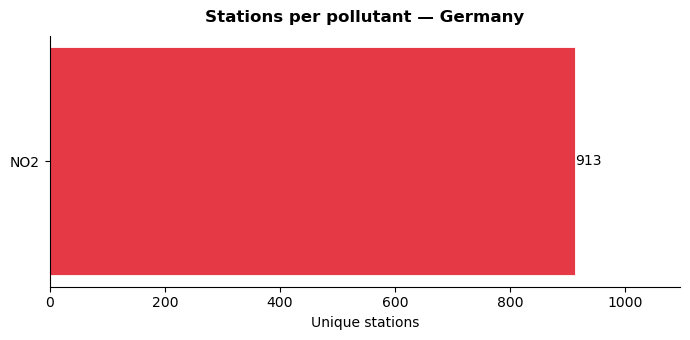

In [10]:
# Station count per pollutant — quick sanity check before downloading data
poll_counts = (
    sensor_pollutant
    .groupby('Air Pollutant')['sensor_uid']
    .nunique()
    .sort_values(ascending=False)
)

POLL_COLORS = {
    'NO2': '#E63946', 'NOX as NO2': '#F4A261',
    'CO':  '#457B9D', 'SO2': '#2A9D8F',
}

fig, ax = plt.subplots(figsize=(7, 3.5))
colors  = [POLL_COLORS.get(p, '#888888') for p in poll_counts.index]
bars    = ax.barh(poll_counts.index, poll_counts.values, color=colors,
                  edgecolor='white', linewidth=0.6, height=0.55)

for bar, val in zip(bars, poll_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Unique stations', fontsize=10)
ax.set_title(f'Stations per pollutant — {selection_label}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlim(0, poll_counts.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 3 - Download EEA Measurements

Submits an asynchronous request to the **EEA Download API**, polls until the ZIP file is ready,
and saves it to disk. The API returns one Parquet file per Sampling Point (sensor) inside the ZIP.

**Pre-flight checks** are run before hitting the API so that common configuration mistakes
(wrong dataset year, no pollutant selected, inverted date range) are caught early.

**Empty archive handling:** If the API returns a valid but empty ZIP (no files inside) after
several retries, it almost certainly means there is no data for this combination of country/bbox,
pollutant, and date range. Recommended fixes are printed inline.

In [11]:
'''
Submit an async download request to the EEA API.
Per API docs: dataset=1 -> E2a (UTD, 2023+), dataset=2 -> E1a (verified, 2013-2022)
'''

import io
W = 56

apiUrl   = cfg['api']['apiUrl']
endpoint = cfg['api']['endpoint']
zip_path = os.path.join(cfg['paths']['thesis_dir'], cfg['paths']['zip_name'])

import re as _re

def _clean_str(s):
    return _re.sub(r'[\x00-\x1f\x7f-\x9f]', '', str(s)).strip()

def _extract_iso2_from_spid(s):
    '''Extract 2-letter ISO-2 from Sampling Point Id.
    EEA formats: SPO.IT..., SPO-AL..., SPO_NO..., IT_..., IT12345...'''
    s = _clean_str(s).upper()
    # SPO separator formats
    m = _re.search(r'SPO[._\-]([A-Z]{2})', s)
    if m:
        code = m.group(1)
        return 'ES' if code == 'SP' else code
    # CountryCode_... format
    m = _re.match(r'^([A-Z]{2})[_\-]', s)
    if m:
        return m.group(1)
    # CountryCode followed by digits
    m = _re.match(r'^([A-Z]{2})\d', s)
    if m:
        return m.group(1)
    return None

# Read eea_sensors_meta — try multiple encodings
_meta_path = cfg['paths']['stations_csv']  # points to eea_sensor_meta.csv
_tmp2 = None
for _enc in ('utf-8', 'utf-8-sig', 'cp1252', 'latin1'):
    try:
        _df = pd.read_csv(_meta_path, encoding=_enc,
                          usecols=['Country', 'Sampling Point Id'],
                          low_memory=False, on_bad_lines='skip').dropna()
        if len(_df) > 0:
            _tmp2 = _df
            print(f'  Loaded metadata ({len(_df):,} rows, encoding: {_enc})')
            break
    except Exception:
        continue

if _tmp2 is None:
    raise IOError(f'Could not read metadata from {_meta_path}')

_tmp2['Country'] = _tmp2['Country'].apply(_clean_str)
_tmp2['iso2']    = _tmp2['Sampling Point Id'].apply(_extract_iso2_from_spid)
_tmp2 = _tmp2.dropna(subset=['iso2'])

country_to_iso2 = _tmp2.groupby('Country')['iso2'].agg(lambda x: sorted(set(x))[0]).to_dict()

if cfg['mode'] == 'country':
    _country_clean = _clean_str(cfg['country'])
    iso2 = country_to_iso2.get(_country_clean)
    if not iso2:
        iso2 = {k.lower(): v for k, v in country_to_iso2.items()}.get(_country_clean.lower())
    if not iso2:
        print(f'  Available countries: {sorted(country_to_iso2.keys())}')
        raise ValueError(f"Cannot derive ISO-2 for '{cfg['country']}'. "
                         "Check country name matches eea_sensor_meta.csv exactly.")
    print(f"  ISO-2 : {iso2}  ('{_country_clean}')")
else:
    iso2 = None

if cfg['start_date'] is None or cfg['end_date'] is None:
    raise ValueError('cfg start_date / end_date are None — save configuration first.')

# Per EEA API docs: 1 = E2a (UTD, 2023+),  2 = E1a (verified, 2013-2022)
dataset_id    = cfg['api']['dataset']
dataset_label = {1: 'E2a (up-to-date, 2023+)', 2: 'E1a (verified, 2013-2022)'}.get(dataset_id, str(dataset_id))
start_year    = cfg['start_date'].year

_errors = []
if cfg['start_date'] > cfg['end_date']:
    _errors.append(f'Start date is after End date.')
if dataset_id == 2 and start_year > 2022:
    _errors.append(f'E1a (dataset=2) covers 2013-2022 but start year={start_year}. Use E2a (dataset=1).')
if dataset_id == 1 and start_year < 2023:
    _errors.append(f'E2a (dataset=1) covers 2023+ but start year={start_year}. Use E1a (dataset=2).')
if not cfg.get('pollutants'):
    _errors.append('No pollutants selected.')

if _errors:
    for _e in _errors:
        print(f'  ❌ {_e}')
    raise ValueError('Fix the above issues in Step 1 and re-run.')

print('  Pre-flight checks passed ✅')

_start_dt = cfg['start_date'].replace(hour=0,  minute=0,  second=0)
_end_dt   = cfg['end_date'].replace(  hour=23, minute=59, second=59)

request_body = {
    'countries':       [iso2] if cfg['mode'] == 'country' else [],
    'cities':          [],
    'pollutants':      cfg['pollutants'],
    'dataset':         dataset_id,
    'dateTimeStart':   _start_dt.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'dateTimeEnd':     _end_dt.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'aggregationType': cfg['aggregationType'],
    'email':           cfg['api']['email'],
}

print('_' * W)
print('  Step 3 - EEA Measurements Download')
print('-' * W)
print(f'  Dataset    : {dataset_label}')
print(f"  Pollutants : {', '.join(cfg['pollutants'])}")
print(f"  Period     : {_start_dt.date()} -> {_end_dt.date()}")
print(f"  Mode       : {cfg['mode']}" + (f' ({iso2})' if iso2 else ' (bbox)'))
print('_' * W)

response = requests.post(f'{apiUrl}{endpoint}', json=request_body, timeout=30)
print(f'\n  API response status : {response.status_code}')
if response.status_code != 200:
    raise Exception('Download request failed: ' + response.text)

polling_url = response.text.strip()
print(f'  Polling URL         : {polling_url}')
print(f"  Polling every {cfg['api']['poll_seconds']}s (timeout: {cfg['api']['timeout_seconds']}s) ...")

t_start     = datetime.now()
_empty_hits = 0
_POLL_MAX_EMPTY = 3

while True:
    elapsed = (datetime.now() - t_start).total_seconds()
    if elapsed > cfg['api']['timeout_seconds']:
        raise TimeoutError(f'Download timed out after {elapsed:.0f}s.')

    try:
        r = requests.get(polling_url, timeout=30)
    except requests.exceptions.Timeout:
        print(f'  [{elapsed:.0f}s] GET timeout, retrying...')
        time.sleep(cfg['api']['poll_seconds'])
        continue
    except requests.exceptions.RequestException as _exc:
        print(f'  [{elapsed:.0f}s] Network error: {_exc}, retrying...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    if r.status_code == 404:
        print(f'  [{elapsed:.0f}s] Not ready yet (404)...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    if r.status_code != 200:
        print(f'  [{elapsed:.0f}s] Unexpected status {r.status_code}, retrying...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    n_bytes = len(r.content)
    try:
        _zf    = zipfile.ZipFile(io.BytesIO(r.content))
        _names = _zf.namelist()
        _zf.close()
        _is_zip = True
    except Exception:
        _is_zip = False
        _names  = []

    if _is_zip and _names:
        with open(zip_path, 'wb') as _fout:
            _fout.write(r.content)
        print(f'\n  Download complete in {elapsed:.0f}s ✅')
        print(f'  File size  : {n_bytes / 1024:.1f} KB  ({len(_names)} file(s) inside)')
        print(f'  Saved to   : {zip_path}')
        print('  Next: run the unzip cell.')
        break

    if _is_zip and not _names:
        _empty_hits += 1
        print(f'  [{elapsed:.0f}s] Empty ZIP (hit {_empty_hits}/{_POLL_MAX_EMPTY})...')
        if _empty_hits >= _POLL_MAX_EMPTY:
            print()
            print('  ❌ EEA API returned an empty archive. No data for this combination:')
            print(f'    Country   : {cfg.get("country") or "bbox"}')
            print(f'    Pollutants: {cfg["pollutants"]}')
            print(f'    Period    : {_start_dt.date()} -> {_end_dt.date()}')
            print(f'    Dataset   : {dataset_label}  (API value={dataset_id})')
            print()
            print('  Fixes to try:')
            print('  1. Wrong dataset? E2a(=1) covers 2023+, E1a(=2) covers 2013-2022.')
            print('  2. Widen the date range.')
            print('  3. Try a different pollutant.')
            print('  4. Check what the country of interest actually has by going to: https://eeadmz1-downloads-webapp.azurewebsites.net ')
            raise RuntimeError('Empty archive — see diagnostics above.')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    _raw = r.content.decode('utf-8', errors='replace')[:300]
    print(f'  [{elapsed:.0f}s] Non-ZIP response ({n_bytes} bytes): {_raw!r}')
    time.sleep(cfg['api']['poll_seconds'])
    continue


  Loaded metadata (15,513 rows, encoding: utf-8)
  ISO-2 : DE  ('Germany')
  Pre-flight checks passed ✅
________________________________________________________
  Step 3 - EEA Measurements Download
--------------------------------------------------------
  Dataset    : E1a (verified, 2013-2022)
  Pollutants : NO2
  Period     : 2022-01-01 -> 2022-01-05
  Mode       : country (DE)
________________________________________________________

  API response status : 200
  Polling URL         : https://eeadmz1batchservice02.blob.core.windows.net/downloads/72a4d8b5-73ea-474c-bf57-08d24f398db7/ParquetFile.zip
  Polling every 20s (timeout: 3600s) ...
  [0s] Not ready yet (404)...
  [21s] Not ready yet (404)...
  [41s] Not ready yet (404)...
  [62s] Not ready yet (404)...

  Download complete in 82s ✅
  File size  : 874.0 KB  (409 file(s) inside)
  Saved to   : C:\Users\Administrador\Downloads\Thesis\EEA_download.zip
  Next: run the unzip cell.


## Step 4a - Unzip & List Parquet Files

Extracts the downloaded ZIP into a temporary folder and collects the paths of all Parquet files.
Each file corresponds to one Sampling Point ID (a single sensor-pollutant combination).

In [12]:
# Extract the downloaded ZIP and collect all Parquet file paths.
W = 56
extract_dir = cfg['paths']['extract_dir']

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

parquet_files = []
for root, _, files in os.walk(extract_dir):
    for f in files:
        if f.lower().endswith('.parquet'):
            parquet_files.append(os.path.join(root, f))

print(f'  Parquet files found : {len(parquet_files):,}')
if parquet_files:
    print(f'  First file          : {os.path.basename(parquet_files[0])}')
print('\n  Next: run Step 4b to build the wide dataset.')

  Parquet files found : 409
  First file          : SPO.DE_DEBB021_NO2_dataGroup1.parquet

  Next: run Step 4b to build the wide dataset.


## Step 4b - Build Wide Dataset

Reads all Parquet files, matches each Sampling Point ID to the cleaned station metadata,
and pivots the long-format measurement data into a **wide table** with one column per pollutant.
A companion column for the measurement unit is also retained (e.g. `SO2_unit`).

The key used for matching is a normalised version of the Sampling Point ID
(country prefix stripped, separators standardised). This makes the merge robust
across the different ID formats used in the API files vs. the metadata CSV.

In [13]:
'''
Build the wide measurement table from all downloaded Parquet files.
1. Normalise the Sampling Point ID key to match metadata.
2. Merge to attach coordinates and station codes.
3. Pivot to wide: one column per pollutant (values) + one per unit.
'''

W = 56

def spo_key_simple(s):
    '''Strip country prefix and normalise to uppercase key.'''
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    s = re.sub(r'^[A-Z]{2}\s*/\s*', '', s)
    return s

meta_sp = df_clean_sel.rename(columns={'Sampling Point Id': 'Sampling Point Id_meta'}).copy()
meta_sp['spo_key'] = meta_sp['Sampling Point Id_meta'].apply(spo_key_simple)
meta_sp = meta_sp.drop_duplicates('spo_key')

base_parts = []
skipped    = 0

print(f'  Processing {len(parquet_files):,} Parquet files...')
for meas_file in tqdm(parquet_files, desc='  Reading parquets', unit='file'):
    d = pd.read_parquet(meas_file)
    if len(d) == 0:
        skipped += 1
        continue

    d['spo_key'] = d['Samplingpoint'].apply(spo_key_simple)
    dm = d.merge(meta_sp, on='spo_key', how='left')

    dm['Start'] = pd.to_datetime(dm['Start'], errors='coerce', utc=True)
    dm['Value'] = pd.to_numeric(dm['Value'], errors='coerce')

    _base_cols = ['Longitude', 'Latitude', 'Start', 'Air Pollutant', 'Value', 'Unit']
    _optional  = ['sensor_uid', 'Country', 'Air Quality Station Name',
                  'Air Quality Network Name', 'Air Quality Station EoI Code',
                  'Air Quality Station Nat Code']
    part_cols  = [c for c in _optional if c in dm.columns] + _base_cols

    part = dm.dropna(subset=['Longitude','Latitude','Start','Air Pollutant','Value'])[part_cols].copy()
    base_parts.append(part)

base_all_full = pd.concat(base_parts, ignore_index=True)

_index_candidates = [
    'sensor_uid', 'Longitude', 'Latitude', 'Start',
    'Country', 'Air Quality Station Name',
    'Air Quality Station EoI Code', 'Air Quality Station Nat Code',
]
index_cols = [c for c in _index_candidates if c in base_all_full.columns]

wide_all_full = (
    base_all_full
    .pivot_table(index=index_cols, columns='Air Pollutant', values='Value', aggfunc='first')
    .reset_index()
)
wide_all_full.columns.name = None

wide_units_full = (
    base_all_full
    .pivot_table(index=index_cols, columns='Air Pollutant', values='Unit', aggfunc='first')
    .reset_index()
)
wide_units_full.columns.name = None
unit_cols = [c for c in wide_units_full.columns if c not in index_cols]
wide_units_full = wide_units_full.rename(columns={c: f'{c}_unit' for c in unit_cols})

wide_all_full_with_units = wide_all_full.merge(wide_units_full, on=index_cols, how='left')

out_dir   = cfg['paths']['thesis_dir']
wide_path = os.path.join(out_dir, 'wide_output.parquet')
wide_csv  = os.path.join(out_dir, 'wide_output.csv')
wide_all_full_with_units.to_parquet(wide_path, index=False)
wide_all_full_with_units.to_csv(wide_csv, index=False)

print(f'\n  Wide dataset built')
print(f'  Parquet files processed  : {len(parquet_files) - skipped:,}  (skipped empty: {skipped})')
print(f'  Total measurement rows   : {len(base_all_full):,}')
print(f'  Wide table shape         : {wide_all_full_with_units.shape[0]:,} rows x {wide_all_full_with_units.shape[1]} columns')
print(f'  Pollutants found         : {sorted(base_all_full["Air Pollutant"].unique())}')
print(f'  Saved (parquet)          : {wide_path}')
print(f'  Saved (csv)              : {wide_csv}')
print('  Next: run Step 4c to build the time-window summary.')
display(wide_all_full_with_units.head())

  Processing 409 Parquet files...


  Reading parquets: 100%|██████████████████████████████████████████████████████████| 409/409 [00:10<00:00, 39.81file/s]



  Wide dataset built
  Parquet files processed  : 409  (skipped empty: 0)
  Total measurement rows   : 35,712
  Wide table shape         : 35,712 rows x 8 columns
  Pollutants found         : ['NO2']
  Saved (parquet)          : C:\Users\Administrador\Downloads\Thesis\wide_output.parquet
  Saved (csv)              : C:\Users\Administrador\Downloads\Thesis\wide_output.csv
  Next: run Step 4c to build the time-window summary.


,sensor_uid,Longitude,Latitude,Start,Country,Air Quality Station Name,NO2,NO2_unit
0,Germany_Aachen-Burtscheid_6.09383_50.75473,6.09383,50.75473,2022-01-01 00:00:00+00:00,Germany,Aachen-Burtscheid,6.639,ug.m-3
1,Germany_Aachen-Burtscheid_6.09383_50.75473,6.09383,50.75473,2022-01-01 01:00:00+00:00,Germany,Aachen-Burtscheid,5.018,ug.m-3
2,Germany_Aachen-Burtscheid_6.09383_50.75473,6.09383,50.75473,2022-01-01 02:00:00+00:00,Germany,Aachen-Burtscheid,4.428,ug.m-3
3,Germany_Aachen-Burtscheid_6.09383_50.75473,6.09383,50.75473,2022-01-01 03:00:00+00:00,Germany,Aachen-Burtscheid,3.869,ug.m-3
4,Germany_Aachen-Burtscheid_6.09383_50.75473,6.09383,50.75473,2022-01-01 04:00:00+00:00,Germany,Aachen-Burtscheid,4.025,ug.m-3


## Step 4c - Time-Window Summary

Classifies each hourly measurement as belonging to either the **previous** or **current** time window,
then computes per-station daily means for each window.

The output (`summary`) has one row per station × day, with columns `prev_mean` and `curr_mean`.
This is the table that will ultimately be enriched with ERA5 meteorology and Sentinel-5P data.

> **Note on EEA sentinel value −9999:** The EEA uses −9999 as a missing-data sentinel.
> This step replaces it with `NaN` before computing means, so it does not bias the averages.

In [14]:
'''Build the per-station per-day summary (prev_mean, curr_mean).'''

W = 56

pollutant_selected = cfg['pollutants'][0]
print(f'  Pollutant selected for summary : {pollutant_selected}')

eea = wide_all_full_with_units.copy()

if pollutant_selected not in eea.columns:
    available = [c for c in eea.columns if c in ['SO2','CO','NO2','NOX as NO2']]
    raise ValueError(f"Pollutant '{pollutant_selected}' not found. Available: {available}")

# Replace EEA sentinel value -9999 with NaN before any calculation
eea[pollutant_selected] = eea[pollutant_selected].replace(-9999, np.nan)
eea[pollutant_selected] = pd.to_numeric(eea[pollutant_selected], errors='coerce')
before_drop = len(eea)
eea = eea.dropna(subset=[pollutant_selected]).copy()
print(f'  Rows after dropping NaN [{pollutant_selected}] : {len(eea):,}  (removed {before_drop - len(eea):,})')

_id_col = ('Air Quality Station EoI Code' if 'Air Quality Station EoI Code' in eea.columns
           else 'sensor_uid' if 'sensor_uid' in eea.columns
           else eea.columns[0])
merged = pd.DataFrame({
    'idsensore': eea[_id_col].astype(str),
    'pollutant': pollutant_selected,
    'data':      pd.to_datetime(eea['Start'], utc=True, errors='coerce'),
    'value':     pd.to_numeric(eea[pollutant_selected], errors='coerce'),
    'lat':       pd.to_numeric(eea['Latitude'],  errors='coerce'),
    'lng':       pd.to_numeric(eea['Longitude'], errors='coerce'),
    'provincia': 'EEA',
})
merged = merged.dropna(subset=['data','value','lat','lng']).copy()
merged['date'] = merged['data'].dt.date

def classify_period(ts, date_analysis):
    '''
    Classify a UTC timestamp into "previous" or "current" window.

    The windows are defined in cfg['time_windows'] as HH:MM strings.
    The previous window may span midnight (prev_start is on the day before).
    '''
    if pd.isna(ts):
        return None
    ts = pd.to_datetime(ts, utc=True)
    prev_s, prev_e = cfg['time_windows']['prev']
    curr_s, curr_e = cfg['time_windows']['curr']
    date_dt  = pd.to_datetime(date_analysis).date()
    prev_day = (pd.to_datetime(date_dt) - pd.Timedelta(days=1)).date()
    curr_start = pd.to_datetime(f'{date_dt} {curr_s}', utc=True)
    curr_end   = pd.to_datetime(f'{date_dt} {curr_e}', utc=True)
    prev_start = pd.to_datetime(f'{prev_day} {prev_s}', utc=True)
    prev_end   = pd.to_datetime(f'{date_dt} {prev_e}', utc=True)
    if curr_start <= ts <= curr_end:
        return 'current'
    elif prev_start <= ts <= prev_end:
        return 'previous'
    return None

all_summaries = []
date_range    = pd.date_range(cfg['start_date'], cfg['end_date'], freq='D')

print(f'\n  Computing daily summaries for {len(date_range)} day(s)...')
for date_analysis in tqdm(date_range, desc='  Summarising', unit='day'):
    prev_day = date_analysis - pd.Timedelta(days=1)
    subset   = merged[merged['data'].dt.date.isin([prev_day.date(), date_analysis.date()])].copy()
    if subset.empty:
        continue
    subset['period'] = subset['data'].apply(lambda ts: classify_period(ts, date_analysis.date()))
    subset = subset.dropna(subset=['period'])
    if subset.empty:
        continue
    day_summary = (
        subset
        .groupby(['idsensore','lat','lng','provincia','period'])['value']
        .mean().reset_index()
        .pivot(index=['idsensore','lat','lng','provincia'], columns='period', values='value')
        .reset_index()
        .rename(columns={'current': 'curr_mean', 'previous': 'prev_mean'})
    )
    day_summary['pollutant'] = pollutant_selected
    day_summary['date']      = date_analysis.date()
    all_summaries.append(day_summary)

if not all_summaries:
    raise RuntimeError('No summaries generated — check date range and time windows.')

summary = pd.concat(all_summaries, ignore_index=True)
for col in ['curr_mean', 'prev_mean']:
    if col not in summary.columns:
        summary[col] = np.nan

summary_gdf = gpd.GeoDataFrame(
    summary.copy(),
    geometry=gpd.points_from_xy(summary['lng'], summary['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32632')

print(f'\n  Time-window summary complete')
print(f'  Days processed             : {len(all_summaries)}')
print(f'  Total summary rows         : {len(summary):,}')
print(f'  Unique stations in summary : {summary["idsensore"].nunique():,}')
print(f'  Pollutant                  : {pollutant_selected}')
print(f'  summary_gdf shape          : {summary_gdf.shape}')
print('  Next: draw your analysis bbox on the map (Step 5).')
display(summary.head())

  Pollutant selected for summary : NO2
  Rows after dropping NaN [NO2] : 35,712  (removed 0)

  Computing daily summaries for 5 day(s)...


  Summarising: 100%|████████████████████████████████████████████████████████████████████| 5/5 [01:59<00:00, 23.93s/day]


  Time-window summary complete
  Days processed             : 5
  Total summary rows         : 1,860
  Unique stations in summary : 372
  Pollutant                  : NO2
  summary_gdf shape          : (1860, 9)
  Next: draw your analysis bbox on the map (Step 5).


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date
0,Germany_Aachen-Burtscheid_6.09383_50.75473,50.75473,6.09383,EEA,2.936750,4.172167,NO2,2022-01-01
1,Germany_Aalen_10.09629_48.84792,48.84792,10.09629,EEA,8.117250,11.396750,NO2,2022-01-01
2,Germany_Allertal_9.62295_52.82943,52.82943,9.62295,EEA,8.717365,5.493051,NO2,2022-01-01
3,Germany_Altenburg Theaterplatz_12.43762_50.98776,50.98776,12.43762,EEA,9.161212,6.078804,NO2,2022-01-01
4,Germany_Altes Land_9.68503_53.52418,53.52418,9.68503,EEA,6.208730,-78.170726,NO2,2022-01-01


### Step 4c — Concentration Distribution

These histograms show the distribution of the `prev_mean` and `curr_mean` concentrations
across all stations and days. A large spread or many zeros may indicate sparse data.

In [ ]:
# Quick distribution check for the two time windows
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

for ax, col, color, label in [
    (axes[0], 'prev_mean', '#457B9D', 'Previous window'),
    (axes[1], 'curr_mean', '#E63946', 'Current window'),
]:
    vals = summary[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {vals.mean():.2f}')
    ax.set_title(f'{label} — {pollutant_selected}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{pollutant_selected} concentration (µg/m³)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribution of ground-level concentrations', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5 - Draw Analysis Bounding Box

Use the **rectangle tool** on the map below to draw your analysis area, then click **Save bbox to cfg**.

The bbox serves two purposes:
1. **Clips the sensor set** so only stations inside the drawn area proceed to the ERA5 and Sentinel-5P steps.
2. **Defines the ERA5 download area** (with a 0.5° buffer added automatically in Step 7).

> You can redraw the rectangle as many times as needed before saving. Only the last drawn shape is used.

In [15]:
# Center the interactive map on the sensor coverage
s = summary_gdf.to_crs('EPSG:4326').copy()
center_lat = float(s.geometry.y.mean())
center_lon = float(s.geometry.x.mean())

m_draw = geemap.Map(center=(center_lat, center_lon), zoom=7)
try:
    m_draw.add_points_from_xy(s, x='lng', y='lat')
except Exception:
    pass

m_draw.add_draw_control()
dc = m_draw.draw_control
dc.rectangle    = {'shapeOptions': {'fillOpacity': 0.1}}
dc.polygon = dc.polyline = dc.circle = dc.circlemarker = dc.marker = {}

_last_bbox  = {'bbox': None}
out_draw    = widgets.Output()
btn_draw    = widgets.Button(description='Save bbox to cfg', button_style='success',
                             layout=widgets.Layout(width='200px', margin='8px 0 0 0'))

def _on_draw(target, action, geo_json):
    '''Capture the drawn rectangle as [minx, miny, maxx, maxy].'''
    geom = geo_json.get('geometry', {})
    if geom.get('type') != 'Polygon':
        return
    ring = geom.get('coordinates', [[]])[0]
    lons = [p[0] for p in ring]
    lats = [p[1] for p in ring]
    _last_bbox['bbox'] = [min(lons), min(lats), max(lons), max(lats)]
    with out_draw:
        clear_output()
        print(f"  Bbox captured (not yet saved) : {_last_bbox['bbox']}")
        print('  Click Save bbox to cfg to confirm.')

dc.on_draw(_on_draw)

def _save_bbox(_):
    with out_draw:
        if _last_bbox['bbox'] is None:
            print('  Draw a rectangle first — no bbox captured yet.')
            return
        cfg['bbox']    = _last_bbox['bbox']
        cfg['mode']    = 'bbox'
        cfg['aoi_gee'] = ee.Geometry.Rectangle(cfg['bbox'])
        print(f"  cfg bbox saved : {cfg['bbox']}")
        print('  Next: run the clip cell.')

btn_draw.on_click(_save_bbox)
display(m_draw, btn_draw, out_draw)

Map(center=[51.008453172043005, 10.231642069892473], controls=(WidgetControl(options=['position', 'transparent…

Button(button_style='success', description='Save bbox to cfg', layout=Layout(margin='8px 0 0 0', width='200px'…

Output()

## Step 5b - Clip Sensors to Bbox

Applies the drawn bounding box to the time-window summary, retaining only stations that fall
within the area. A before/after count is printed so you can verify the clip is working as expected.

In [16]:
'''
Clip summary_gdf to the drawn bbox.
Reports how many stations were retained vs removed.
'''
W = 56

if not cfg.get('bbox'):
    raise ValueError("cfg['bbox'] is missing — draw and save a rectangle first (Step 5).")

minx, miny, maxx, maxy = cfg['bbox']
s_wgs = summary_gdf.to_crs('EPSG:4326').copy()
total_before    = len(s_wgs)
stations_before = s_wgs['idsensore'].nunique()

mask = (
    (s_wgs.geometry.x >= minx) & (s_wgs.geometry.x <= maxx) &
    (s_wgs.geometry.y >= miny) & (s_wgs.geometry.y <= maxy)
)
summary_gdf_clip_wgs = s_wgs.loc[mask].copy()
summary_gdf_clip     = summary_gdf_clip_wgs.to_crs('EPSG:32632')
stations_after = summary_gdf_clip_wgs['idsensore'].nunique()

print(f'  Bbox                    : {cfg["bbox"]}')
print(f'  Rows before clip        : {total_before:,}')
print(f'  Rows after clip         : {len(summary_gdf_clip_wgs):,}  (removed {total_before - len(summary_gdf_clip_wgs):,})')
print(f'  Unique stations before  : {stations_before:,}')
print(f'  Unique stations after   : {stations_after:,}  (removed {stations_before - stations_after:,})')
print('  Next: build the spatial interpolation grid (Step 6).')
display(summary_gdf_clip_wgs.head())

  Bbox                    : [8.634384, 50.094006, 8.771668, 50.160916]
  Rows before clip        : 1,860
  Rows after clip         : 10  (removed 1,850)
  Unique stations before  : 372
  Unique stations after   : 2  (removed 370)
  Next: build the spatial interpolation grid (Step 6).


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date,geometry
111,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,26.459204,20.124637,NO2,2022-01-01,POINT (8.69191 50.12459)
112,Germany_Frankfurt Ost_8.74634_50.12533,50.12533,8.74634,EEA,16.810966,12.118443,NO2,2022-01-01,POINT (8.74634 50.12533)
483,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,31.485360,38.171632,NO2,2022-01-02,POINT (8.69191 50.12459)
484,Germany_Frankfurt Ost_8.74634_50.12533,50.12533,8.74634,EEA,20.628821,26.937362,NO2,2022-01-02,POINT (8.74634 50.12533)
855,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,29.818112,17.981429,NO2,2022-01-03,POINT (8.69191 50.12459)


## Step 6 - Build Spatial Interpolation Grid

Constructs a **regular lat/lon grid** over the sensor domain.
The grid resolution is set to 90% of the minimum inter-sensor distance,
which ensures at least one grid point sits between any two neighbouring stations.

> The grid extent is derived from the **actual sensor coordinates** (not directly from `cfg['bbox']`)
> to avoid empty-area issues when the drawn bbox is wider than the sensor coverage.

In [17]:
'''
Build a regular point grid over the clipped sensor domain.
Extent is derived from actual sensor coordinates, NOT cfg['bbox'] directly,
to avoid empty-area issues when the drawn bbox is larger than the sensor coverage.
'''

W = 56

sensors = summary_gdf_clip_wgs.drop_duplicates(subset=['idsensore']).copy()

if len(sensors) < 2:
    raise ValueError(
        f'At least 2 sensors required, but only {len(sensors)} found in the clipped area.'
    )

sensor_minx = float(sensors.geometry.x.min())
sensor_miny = float(sensors.geometry.y.min())
sensor_maxx = float(sensors.geometry.x.max())
sensor_maxy = float(sensors.geometry.y.max())
sensor_bbox = [sensor_minx, sensor_miny, sensor_maxx, sensor_maxy]

# Grid resolution: 90% of minimum inter-sensor distance
coords   = np.column_stack([sensors.geometry.x, sensors.geometry.y])
dist_mat = distance_matrix(coords, coords)
dist_mat[dist_mat == 0] = np.nan
min_dist_deg = float(np.nanmin(dist_mat))
res = min_dist_deg * 0.9

xs = np.arange(sensor_minx, sensor_maxx + res, res)
ys = np.arange(sensor_miny, sensor_maxy + res, res)
grid_points = [Point(x, y) for x in xs for y in ys]

grid_gdf = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points, crs='EPSG:4326'
)

grid_wgs84 = grid_gdf.to_crs('EPSG:4326').copy()
grid_wgs84['lat'] = grid_wgs84.geometry.y
grid_wgs84['lon'] = grid_wgs84.geometry.x

print(f'  Clipped sensors used     : {len(sensors):,}')
print(f'  Sensor bbox (WGS-84)     : {sensor_bbox}')
print(f"  cfg bbox                 : {cfg.get('bbox')}")
print(f'  Min inter-sensor dist    : {min_dist_deg:.6f} deg')
print(f'  Grid resolution          : {res:.6f} deg  (= 90% of min dist)')
print(f'  Grid dimensions          : {len(xs)} x {len(ys)} = {len(grid_gdf):,} points')
print('  Next: download ERA5 data (Step 7).')
display(grid_wgs84[['grid_id','lat','lon']].head())

  Clipped sensors used     : 2
  Sensor bbox (WGS-84)     : [8.69191, 50.12458999999999, 8.74634, 50.125329999999984]
  cfg bbox                 : [8.634384, 50.094006, 8.771668, 50.160916]
  Min inter-sensor dist    : 0.054435 deg
  Grid resolution          : 0.048992 deg  (= 90% of min dist)
  Grid dimensions          : 3 x 2 = 6 points
  Next: download ERA5 data (Step 7).


,grid_id,lat,lon
0,0,50.124590,8.691910
1,1,50.173582,8.691910
2,2,50.124590,8.740902
3,3,50.173582,8.740902
4,4,50.124590,8.789893


## Step 7 - ERA5 Download

Downloads ERA5 single-level reanalysis variables from the **Copernicus Climate Data Store (CDS)**
via the `cdsapi` library. One NetCDF file is saved per variable.

A **0.5° buffer** is added around the sensor bbox to ensure the ERA5 domain always
contains grid points (ERA5 native resolution is 0.25°).

**Variables downloaded:**
- 2 m temperature (`t2m`)
- Surface net solar radiation (`ssr`)
- Surface net thermal radiation (`str`)
- Surface pressure (`sp`)
- Total precipitation (`tp`)
- 10 m wind components U and V (`u10`, `v10`)
- Boundary layer height (`blh`)

In [18]:
'''
Download ERA5 single-level variables from the Copernicus CDS.
A 0.5 deg buffer ensures the area always contains ERA5 native grid points.
Previously downloaded files are deleted first to avoid stale data.
'''

W = 56

# Close any open xarray datasets to release Windows file locks before deleting
for _var in ['datasets', 'merged_xr', 'ds_xr']:
    try:
        obj = eval(_var)
        if hasattr(obj, '__iter__') and not hasattr(obj, 'close'):
            for ds in obj: ds.close()
        else:
            obj.close()
    except Exception:
        pass

for f in glob.glob('era5_data/*.nc'):
    try:
        os.remove(f)
    except PermissionError as e:
        print(f'  Could not delete {os.path.basename(f)}: {e}')
        print('  Restart the kernel and re-run from this cell.')

os.makedirs('era5_data', exist_ok=True)

start_date_era5 = pd.to_datetime(cfg['start_date']).date()
end_date_era5   = pd.to_datetime(cfg['end_date']).date()

minx, miny, maxx, maxy = cfg['bbox']
buffer = 0.5
area = [
    round(maxy + buffer, 4),  # north
    round(minx - buffer, 4),  # west
    round(miny - buffer, 4),  # south
    round(maxx + buffer, 4),  # east
]

variables = [
    '2m_temperature', 'surface_net_solar_radiation', 'surface_net_thermal_radiation',
    'surface_pressure', 'total_precipitation',
    '10m_u_component_of_wind', '10m_v_component_of_wind', 'boundary_layer_height',
]

print(f'  Sensor bbox      : {[minx, miny, maxx, maxy]}')
print(f'  ERA5 area (+{buffer} deg): {area}  [N, W, S, E]')
print(f'  Period           : {start_date_era5} -> {end_date_era5}')
print(f'  Variables        : {len(variables)}')
print('  This may take several minutes per variable...')

client = cdsapi.Client()

for var in tqdm(variables, desc='  Downloading ERA5', unit='var'):
    out_file = f'era5_data/{var}_{start_date_era5}_{end_date_era5}.nc'
    if os.path.exists(out_file):
        tqdm.write(f'  Exists, skipping: {var}')
        continue
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis', 'format': 'netcdf',
            'variable': [var],
            'date': f'{start_date_era5}/{end_date_era5}',
            'time': [f'{h:02d}:00' for h in range(24)],
            'area': area,
        },
        out_file,
    )
    tqdm.write(f'  Saved: {out_file}')

print(f'\n  ERA5 download complete. Run Step 7b to merge and convert units.')

  Sensor bbox      : [8.634384, 50.094006, 8.771668, 50.160916]
  ERA5 area (+0.5 deg): [50.6609, 8.1344, 49.594, 9.2717]  [N, W, S, E]
  Period           : 2022-01-01 -> 2022-01-05
  Variables        : 8
  This may take several minutes per variable...


2026-04-08 11:52:49,532 INFO Request ID is 55687216-cade-4dbf-9e00-93cfcabdb39f
2026-04-08 11:52:50,660 INFO status has been updated to accepted
2026-04-08 11:53:05,098 INFO status has been updated to running
2026-04-08 11:53:12,878 INFO status has been updated to successful


cb8c44aaf9c38dcaac6ef073c6346efd.nc:   0%|          | 0.00/35.4k [00:00<?, ?B/s]

  Saved: era5_data/2m_temperature_2022-01-01_2022-01-05.nc


2026-04-08 11:53:14,113 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-08 11:53:14,118 INFO Request ID is c0171d12-d520-4787-a74b-0812ea82c993
2026-04-08 11:53:14,210 INFO status has been updated to accepted
2026-04-08 11:53:28,138 INFO status has been updated to running
2026-04-08 11:53:47,389 INFO status has been updated to successful


...

e81a01fad24aac2fa3a848ab749dd486.nc:   0%|          | 0.00/36.5k [00:00<?, ?B/s]

  Saved: era5_data/10m_v_component_of_wind_2022-01-01_2022-01-05.nc


2026-04-08 11:56:19,662 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-08 11:56:19,665 INFO Request ID is d2fddd5e-595c-4194-acff-ee618b20d9e5
2026-04-08 11:56:20,073 INFO status has been updated to accepted
2026-04-08 11:56:28,882 INFO status has been updated to running
2026-04-08 11:56:53,152 INFO status has been updated to successful


b744c2b8d651041f427b4e86eeeb64e8.nc:   0%|          | 0.00/36.4k [00:00<?, ?B/s]

  Saved: era5_data/boundary_layer_height_2022-01-01_2022-01-05.nc

  ERA5 download complete. Run Step 7b to merge and convert units.


## Step 7b - Merge ERA5 Files & Convert Units

Merges all individual NetCDF files into a single `xarray.Dataset` and applies unit conversions
so all variables are in human-friendly units:

| Raw variable | Unit | Converted variable | Unit |
|---|---|---|---|
| `t2m` | K | `t2m_c` | °C |
| `sp` | Pa | `sp_hpa` | hPa |
| `ssr` | J/m² | `ssr_kJ` | kJ/m² |
| `str` | J/m² | `str_kJ` | kJ/m² |
| `blh` | m | `blh_km` | km |
| `u10`, `v10` | m/s | `wind_speed` | m/s |

In [19]:
'''
Merge all .nc files and apply unit conversions:
  t2m [K] -> t2m_c [C]
  sp [Pa] -> sp_hpa [hPa]
  ssr/str [J] -> kJ
  blh [m] -> km
  u10/v10 -> wind_speed [m/s]
'''

W = 56

folder = 'era5_data'
files  = sorted(glob.glob(os.path.join(folder, '*.nc')))
if not files:
    raise FileNotFoundError('No .nc files found in era5_data/ — run the download cell first.')

datasets  = [xr.open_dataset(f) for f in files]
merged_xr = xr.merge(datasets)
ds_xr     = merged_xr.copy()
conversions_done = []

if 't2m'  in ds_xr: ds_xr['t2m_c']      = ds_xr['t2m'] - 273.15;          conversions_done.append('t2m [K] -> t2m_c [°C]')
if 'sp'   in ds_xr: ds_xr['sp_hpa']     = ds_xr['sp'] / 100.0;             conversions_done.append('sp [Pa] -> sp_hpa [hPa]')
if 'ssr'  in ds_xr: ds_xr['ssr_kJ']     = ds_xr['ssr'] / 1000.0;           conversions_done.append('ssr [J/m²] -> ssr_kJ [kJ/m²]')
if 'str'  in ds_xr: ds_xr['str_kJ']     = ds_xr['str'] / 1000.0;           conversions_done.append('str [J/m²] -> str_kJ [kJ/m²]')
if 'blh'  in ds_xr: ds_xr['blh_km']     = ds_xr['blh'] / 1000.0;           conversions_done.append('blh [m] -> blh_km [km]')
if 'u10' in ds_xr and 'v10' in ds_xr:
    ds_xr['wind_speed'] = np.sqrt(ds_xr['u10']**2 + ds_xr['v10']**2)
    conversions_done.append('u10, v10 -> wind_speed [m/s]')

vars_era5 = [v for v in ['t2m_c','sp_hpa','wind_speed','blh_km','tp','ssr_kJ','str_kJ']
             if v in ds_xr.data_vars]

print('  ERA5 files merged & units converted')
print(f'  Files merged        : {len(files)}')
print(f'  Raw variables       : {list(merged_xr.data_vars)}')
print('  Unit conversions    :')
for c in conversions_done:
    print(f'    {c}')
print(f'  Variables for interp: {vars_era5}')

  ERA5 files merged & units converted
  Files merged        : 8
  Raw variables       : ['u10', 'v10', 't2m', 'blh', 'ssr', 'str', 'sp', 'tp']
  Unit conversions    :
    t2m [K] -> t2m_c [°C]
    sp [Pa] -> sp_hpa [hPa]
    ssr [J/m²] -> ssr_kJ [kJ/m²]
    str [J/m²] -> str_kJ [kJ/m²]
    blh [m] -> blh_km [km]
    u10, v10 -> wind_speed [m/s]
  Variables for interp: ['t2m_c', 'sp_hpa', 'wind_speed', 'blh_km', 'tp', 'ssr_kJ', 'str_kJ']


## Step 8 - Interpolate ERA5 on Sensor Grid

Bilinearly interpolates each ERA5 variable onto the regular point grid built in Step 6.
This produces a long-format table with one row per grid point × timestep,
ready to be aggregated over the time windows in Step 8b.

A non-null fraction check on `t2m_c` after interpolation flags cases where
the ERA5 domain does not fully cover the grid (increase the buffer in Step 7 to fix this).

In [20]:
# Bilinearly interpolate ERA5 variables onto the sensor grid for each timestep.
W = 56
results = []
time_steps = ds_xr['valid_time'].values

print(f'  Interpolating {len(vars_era5)} ERA5 vars over {len(time_steps):,} timesteps x {len(grid_wgs84):,} grid points...')

for t in tqdm(time_steps, desc='  ERA5 interpolation', unit='timestep'):
    ds_hour = ds_xr.sel(valid_time=t)
    interp  = ds_hour[vars_era5].interp(
        latitude=(  'points', grid_wgs84['lat']),
        longitude=( 'points', grid_wgs84['lon'])
    )
    interp_df = interp.to_dataframe().reset_index(drop=True)
    interp_df['valid_time'] = pd.to_datetime(t)
    interp_df['grid_id']    = grid_wgs84['grid_id'].values
    interp_df['lat']        = grid_wgs84['lat'].values
    interp_df['lon']        = grid_wgs84['lon'].values
    results.append(interp_df)

era5_on_grid = pd.concat(results, ignore_index=True)
nn_frac = era5_on_grid['t2m_c'].notna().mean() if 't2m_c' in era5_on_grid else None

print(f'\n  ERA5 interpolation complete')
print(f'  Output shape            : {era5_on_grid.shape[0]:,} rows x {era5_on_grid.shape[1]} columns')
print(f'  Grid points             : {len(grid_wgs84):,}')
print(f'  Timesteps               : {len(time_steps):,}')
if nn_frac is not None:
    status = '(OK)' if nn_frac > 0.9 else '(LOW — check ERA5 area coverage)'
    print(f'  Non-null fraction t2m_c : {nn_frac:.2%}  {status}')
display(era5_on_grid.head())

  Interpolating 7 ERA5 vars over 120 timesteps x 6 grid points...


  ERA5 interpolation: 100%|████████████████████████████████████████████████████| 120/120 [00:02<00:00, 49.77timestep/s]


  ERA5 interpolation complete
  Output shape            : 720 rows x 15 columns
  Grid points             : 6
  Timesteps               : 120
  Non-null fraction t2m_c : 100.00%  (OK)


,t2m_c,sp_hpa,wind_speed,blh_km,tp,ssr_kJ,str_kJ,number,valid_time,expver,latitude,longitude,grid_id,lat,lon
0,11.216019,1003.293940,3.479764,0.413260,0.000002,3.599999e-15,-24.442503,0,2022-01-01,0001,50.124590,8.691910,0,50.124590,8.691910
1,11.220101,1002.583074,3.438902,0.420674,0.000002,3.599999e-15,-25.630544,0,2022-01-01,0001,50.173582,8.691910,1,50.173582,8.691910
2,11.253487,1004.707774,3.498935,0.412582,0.000002,3.599999e-15,-26.345170,0,2022-01-01,0001,50.124590,8.740902,2,50.124590,8.740902
3,11.262519,1004.122101,3.456800,0.419735,0.000002,3.599999e-15,-27.599571,0,2022-01-01,0001,50.173582,8.740902,3,50.173582,8.740902
4,11.196396,1004.115543,3.541668,0.418833,0.000005,3.599999e-15,-26.336001,0,2022-01-01,0001,50.124590,8.789893,4,50.124590,8.789893


### Step 8 - ERA5 Coverage Sanity Check

Verifies that the ERA5 domain fully covers the sensor grid.
If `Grid inside ERA5 lat?` or `Grid inside ERA5 lon?` is `False`,
increase the `buffer` value in Step 7 and re-download.

In [21]:
'''
Verify ERA5 domain fully covers the sensor grid.
If inside_lat or inside_lon is False, increase the buffer in Step 7.
'''

W = 56

lat_min_era5 = float(ds_xr['latitude'].min())
lat_max_era5 = float(ds_xr['latitude'].max())
lon_min_era5 = float(ds_xr['longitude'].min())
lon_max_era5 = float(ds_xr['longitude'].max())

inside_lat = grid_wgs84['lat'].between(lat_min_era5, lat_max_era5).all()
inside_lon = grid_wgs84['lon'].between(lon_min_era5, lon_max_era5).all()

print('  ERA5 coverage check')
print(f'  ERA5 latitude  : {lat_min_era5} -> {lat_max_era5}')
print(f'  GRID latitude  : {float(grid_wgs84["lat"].min()):.6f} -> {float(grid_wgs84["lat"].max()):.6f}')
print(f'  Grid inside ERA5 lat? : {inside_lat}')
print(f'  ERA5 longitude : {lon_min_era5} -> {lon_max_era5}')
print(f'  GRID longitude : {float(grid_wgs84["lon"].min()):.6f} -> {float(grid_wgs84["lon"].max()):.6f}')
print(f'  Grid inside ERA5 lon? : {inside_lon}')
print()
if inside_lat and inside_lon:
    print('  Coverage check PASSED — grid is fully inside ERA5 domain.')
else:
    print('  Coverage check FAILED.')
    if not inside_lat: print('  Latitude mismatch — increase buffer in Step 7.')
    if not inside_lon: print('  Longitude mismatch — increase buffer in Step 7.')

  ERA5 coverage check
  ERA5 latitude  : 49.75 -> 50.5
  GRID latitude  : 50.124590 -> 50.173582
  Grid inside ERA5 lat? : True
  ERA5 longitude : 8.25 -> 9.25
  GRID longitude : 8.691910 -> 8.789893
  Grid inside ERA5 lon? : True

  Coverage check PASSED — grid is fully inside ERA5 domain.


## Step 8b - ERA5 Time-Window Means

Computes per-grid-point means of each ERA5 variable within the **previous** and **current** time windows,
aggregated over all days in the analysis period.

The result is a GeoDataFrame (`era5_gdf`) in EPSG:32632 with one row per grid point
and columns like `t2m_c_current`, `t2m_c_previous`, etc.

In [22]:
# Compute per-grid-point ERA5 means for previous and current windows.
W = 56

era5_df = era5_on_grid.drop(columns=['lat','lon'], errors='ignore').copy()

def assign_period(df, date):
    '''Classify ERA5 timesteps into prev/curr window for a given analysis date.'''
    curr_s = pd.to_datetime(f"{date} {cfg['time_windows']['curr'][0]}")
    curr_e = pd.to_datetime(f"{date} {cfg['time_windows']['curr'][1]}")
    prev_d = (pd.to_datetime(date) - pd.Timedelta(days=1)).date()
    prev_s = pd.to_datetime(f"{prev_d} {cfg['time_windows']['prev'][0]}")
    prev_e = pd.to_datetime(f"{date} {cfg['time_windows']['prev'][1]}")
    def classify(ts):
        if curr_s <= ts <= curr_e: return 'current'
        elif prev_s <= ts <= prev_e: return 'previous'
        return None
    df = df.copy()
    df['period'] = df['valid_time'].apply(classify)
    return df.dropna(subset=['period'])

print('  Computing ERA5 period means over all days...')
era5_period_parts = []
for date_analysis in tqdm(pd.date_range(cfg['start_date'], cfg['end_date'], freq='D'),
                          desc='  ERA5 period means', unit='day'):
    day_classified = assign_period(era5_df, date_analysis.date())
    if not day_classified.empty:
        era5_period_parts.append(day_classified)

if not era5_period_parts:
    raise RuntimeError('No ERA5 timesteps fell inside any time window — check date range and time windows.')

era5_all_periods = pd.concat(era5_period_parts, ignore_index=True)

era5_summary = (
    era5_all_periods
    .groupby(['grid_id','period'], as_index=False)
    .mean(numeric_only=True)
    .pivot(index='grid_id', columns='period')
    .reset_index()
)
era5_summary.columns = [
    '_'.join([str(c) for c in col if c not in ('','None')]).strip('_')
    if isinstance(col, tuple) else str(col)
    for col in era5_summary.columns
]
era5_summary = era5_summary.loc[:, ~era5_summary.columns.str.contains('lat|lon|latitude|longitude', case=False)]
era5_summary = era5_summary.drop(columns=['number_current','number_previous'], errors='ignore')
era5_summary = era5_summary.merge(grid_wgs84[['grid_id','lat','lon']], on='grid_id', how='left')

ordered = ['grid_id','lat','lon'] + sorted(
    [c for c in era5_summary.columns if '_current' in c or '_previous' in c]
)
era5_summary = era5_summary[ordered]

era5_gdf = gpd.GeoDataFrame(
    era5_summary,
    geometry=gpd.points_from_xy(era5_summary['lon'], era5_summary['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32632')

print(f'\n  ERA5 summary built')
print(f'  Grid points   : {len(era5_summary):,}')
print(f'  ERA5 columns  : {[c for c in era5_summary.columns if "_current" in c or "_previous" in c]}')
display(era5_summary.filter(regex='t2m|sp|wind|blh|lat|lon').head())

  Computing ERA5 period means over all days...


  ERA5 period means: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 146.17day/s]


  ERA5 summary built
  Grid points   : 6
  ERA5 columns  : ['blh_km_current', 'blh_km_previous', 'sp_hpa_current', 'sp_hpa_previous', 'ssr_kJ_current', 'ssr_kJ_previous', 'str_kJ_current', 'str_kJ_previous', 't2m_c_current', 't2m_c_previous', 'tp_current', 'tp_previous', 'wind_speed_current', 'wind_speed_previous']


,lat,lon,blh_km_current,blh_km_previous,sp_hpa_current,sp_hpa_previous,t2m_c_current,t2m_c_previous,wind_speed_current,wind_speed_previous
0,50.124590,8.691910,0.724902,0.616109,990.064725,990.368512,8.190875,7.933801,4.176972,4.107547
1,50.173582,8.691910,0.723886,0.612325,989.349048,989.677100,8.158468,7.887982,4.129993,4.045569
2,50.124590,8.740902,0.724733,0.617110,991.483736,991.783818,8.256966,8.015885,4.188178,4.139083
3,50.173582,8.740902,0.723861,0.613226,990.894250,991.217846,8.232458,7.974323,4.138497,4.074638
4,50.124590,8.789893,0.723261,0.616992,990.889118,991.194953,8.194645,7.981082,4.213201,4.155363


### Step 8b - ERA5 Variable Overview

Box plots comparing the distribution of each ERA5 variable between the *previous* and *current*
windows across all grid points. This helps verify that the time windows capture meaningfully
different atmospheric conditions.

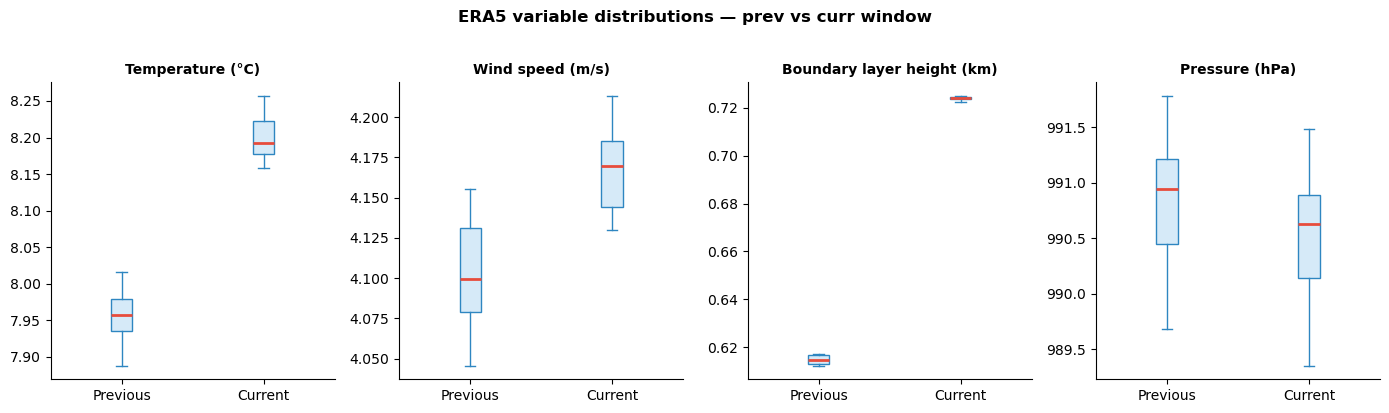

In [23]:
# Compare ERA5 variables between time windows
era5_vars_plot = [
    ('t2m_c',      'Temperature (°C)'),
    ('wind_speed', 'Wind speed (m/s)'),
    ('blh_km',     'Boundary layer height (km)'),
    ('sp_hpa',     'Pressure (hPa)'),
]

n_vars = len([v for v, _ in era5_vars_plot if f'{v}_current' in era5_summary.columns])
if n_vars == 0:
    print('No ERA5 variable columns found — skipping plot.')
else:
    fig, axes = plt.subplots(1, n_vars, figsize=(3.5 * n_vars, 4))
    if n_vars == 1:
        axes = [axes]

    ax_idx = 0
    for var, label in era5_vars_plot:
        col_c = f'{var}_current'
        col_p = f'{var}_previous'
        if col_c not in era5_summary.columns:
            continue
        ax = axes[ax_idx]
        ax.boxplot(
            [era5_summary[col_p].dropna(), era5_summary[col_c].dropna()],
            labels=['Previous', 'Current'],
            patch_artist=True,
            boxprops=dict(facecolor='#D6EAF8', color='#2E86C1'),
            medianprops=dict(color='#E74C3C', linewidth=2),
            whiskerprops=dict(color='#2E86C1'),
            capprops=dict(color='#2E86C1'),
        )
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax_idx += 1

    plt.suptitle('ERA5 variable distributions — prev vs curr window', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Step 9 - Join EEA Sensors + ERA5 (Nearest Neighbour)

Attaches ERA5 meteorological variables to each EEA sensor row by finding the **nearest ERA5 grid point**.
The join is performed in EPSG:32632 (metric) so distances are in metres rather than degrees,
which avoids distortions at higher latitudes.

In [24]:
'''
Join EEA sensor summary with ERA5 grid via spatial nearest-neighbour.
Both GeoDataFrames are in EPSG:32632 (metric) so distances are in metres.
'''

W = 56

era5_vars = [c for c in era5_summary.columns if '_current' in c or '_previous' in c]
print(f'  Attaching {len(era5_vars)} ERA5 variables to {len(summary_gdf_clip):,} EEA sensor rows...')

for var in tqdm(era5_vars, desc='  Nearest-neighbour join', unit='var'):
    nearest_idx = era5_gdf.sindex.nearest(summary_gdf_clip.geometry, return_all=False)[1]
    summary_gdf_clip[var] = era5_gdf.iloc[nearest_idx][var].values

summary_gdf_clip = summary_gdf_clip.to_crs('EPSG:4326')

print(f'\n  EEA + ERA5 join complete')
print(f'  EEA sensor rows         : {len(summary_gdf_clip):,}')
print(f'  Unique stations         : {summary_gdf_clip["idsensore"].nunique():,}')
print(f'  ERA5 variables attached : {len(era5_vars)}')
print(f'  Final dataset columns   : {summary_gdf_clip.shape[1]}')
display(summary_gdf_clip.head())

  Attaching 14 ERA5 variables to 10 EEA sensor rows...


  Nearest-neighbour join: 100%|██████████████████████████████████████████████████████| 14/14 [00:00<00:00, 893.10var/s]


  EEA + ERA5 join complete
  EEA sensor rows         : 10
  Unique stations         : 2
  ERA5 variables attached : 14
  Final dataset columns   : 23


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date,geometry,blh_km_current,...,ssr_kJ_current,ssr_kJ_previous,str_kJ_current,str_kJ_previous,t2m_c_current,t2m_c_previous,tp_current,tp_previous,wind_speed_current,wind_speed_previous
111,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,26.459204,20.124637,NO2,2022-01-01,POINT (8.69191 50.12459),0.724902,...,226.537035,35.913498,-104.806203,-89.527065,8.190875,7.933801,0.000285,0.000375,4.176972,4.107547
112,Germany_Frankfurt Ost_8.74634_50.12533,50.12533,8.74634,EEA,16.810966,12.118443,NO2,2022-01-01,POINT (8.74634 50.12533),0.724733,...,225.000384,35.940956,-104.569732,-89.851729,8.256966,8.015885,0.000297,0.000377,4.188178,4.139083
483,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,31.485360,38.171632,NO2,2022-01-02,POINT (8.69191 50.12459),0.724902,...,226.537035,35.913498,-104.806203,-89.527065,8.190875,7.933801,0.000285,0.000375,4.176972,4.107547
484,Germany_Frankfurt Ost_8.74634_50.12533,50.12533,8.74634,EEA,20.628821,26.937362,NO2,2022-01-02,POINT (8.74634 50.12533),0.724733,...,225.000384,35.940956,-104.569732,-89.851729,8.256966,8.015885,0.000297,0.000377,4.188178,4.139083
855,Germany_Frankfurt Friedberger Landstraße_8.691...,50.12459,8.69191,EEA,29.818112,17.981429,NO2,2022-01-03,POINT (8.69191 50.12459),0.724902,...,226.537035,35.913498,-104.806203,-89.527065,8.190875,7.933801,0.000285,0.000375,4.176972,4.107547


## Step 10 - Sentinel-5P Extraction

Extracts Sentinel-5P column concentration for each EEA sensor location and day using
**Google Earth Engine (GEE)**.

For each day in the analysis range, the daily S5P image is reduced to a mean value at
each sensor point using a buffer equal to `sentinel_scale_km` (5.5 km — approximately
one S5P pixel). `None` is returned when no overpass covered the location on that day.

**Supported pollutants:**

| Pollutant | GEE Collection | Band |
|---|---|---|
| NO2 | `COPERNICUS/S5P/OFFL/L3_NO2` | `NO2_column_number_density` |
| CO  | `COPERNICUS/S5P/OFFL/L3_CO`  | `CO_column_number_density`  |
| O3  | `COPERNICUS/S5P/OFFL/L3_O3`  | `O3_column_number_density`  |
| SO2 | `COPERNICUS/S5P/OFFL/L3_SO2` | `SO2_column_number_density` |

In [25]:
# Pollutant alias map for Sentinel-5P band lookup
def normalize_name(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode()
    return re.sub(r'[^a-z0-9]+', ' ', s.lower()).strip()

ALIASES = {
    'no2': {'no2','NOX as NO2','nitrogen dioxide','diossido di azoto'},
    'co':  {'co', 'carbon monoxide', 'monossido di carbonio'},
    'o3':  {'o3', 'ozone', 'ozono'},
    'so2': {'so2','sulfur dioxide', 'diossido di zolfo'},
}
LOOKUP = {normalize_name(n): k for k, names in ALIASES.items() for n in names}

def get_pollutant_key(pollutant):
    k = LOOKUP.get(normalize_name(pollutant))
    if not k:
        raise ValueError(f"No Sentinel-5P mapping for '{pollutant}'.")
    return k

In [26]:
# Extract S5P column concentration for each EEA sensor location and day.
W = 56

S5P_BANDS = {
    'no2': {'collection':'COPERNICUS/S5P/OFFL/L3_NO2',  'band':'NO2_column_number_density', 'unit':'mol/m2','scale':5500},
    'co':  {'collection':'COPERNICUS/S5P/OFFL/L3_CO',   'band':'CO_column_number_density',  'unit':'mol/m2','scale':5500},
    'o3':  {'collection':'COPERNICUS/S5P/OFFL/L3_O3',   'band':'O3_column_number_density',  'unit':'mol/m2','scale':5500},
    'so2': {'collection':'COPERNICUS/S5P/OFFL/L3_SO2',  'band':'SO2_column_number_density', 'unit':'mol/m2','scale':5500},
}

pollutant_key = get_pollutant_key(cfg['pollutants'][0])
s5p_cfg       = S5P_BANDS[pollutant_key]
dataset_id    = s5p_cfg['collection']
band_name     = s5p_cfg['band']

print(f'  Pollutant key  : {pollutant_key.upper()}')
print(f'  S5P collection : {dataset_id}')
print(f'  Band           : {band_name}')
print(f"  Date range     : {cfg['start_date'].date()} -> {cfg['end_date'].date()}")

def get_s5p_value(lon, lat, s5p_image):
    '''Sample S5P mean value at a single point via GEE.'''
    point = ee.Geometry.Point(lon, lat)
    value = s5p_image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=point, scale=s5p_cfg['scale']
    ).get(band_name)
    return value.getInfo()

all_results = []
s5p_col     = f"Sentinel 5P {pollutant_key.upper()} Concentration (mol/m2)"

for date_analysis in tqdm(pd.date_range(cfg['start_date'], cfg['end_date'], freq='D'),
                          desc='  Extracting S5P', unit='day'):
    start_s = str(date_analysis.date())
    end_s   = str((date_analysis + pd.Timedelta(days=1)).date())

    s5p_image = (
        ee.ImageCollection(dataset_id)
        .filterDate(start_s, end_s)
        .filterBounds(cfg['aoi_gee'])
        .select(band_name)
        .mean()
    )

    df_day = summary_gdf_clip[summary_gdf_clip['date'] == pd.to_datetime(start_s).date()].copy()
    if df_day.empty:
        tqdm.write(f'  No EEA data for {start_s}, skipping.')
        continue

    df_day[s5p_col]               = [get_s5p_value(lon, lat, s5p_image)
                                     for lon, lat in zip(df_day['lng'], df_day['lat'])]
    df_day['Sentinel 5P Dataset'] = dataset_id
    df_day['Sentinel 5P Band']    = band_name
    df_day['Sentinel 5P Units']   = s5p_cfg['unit']
    df_day['Sentinel 5P Date']    = start_s
    all_results.append(df_day)
    tqdm.write(f'  {start_s} — {len(df_day):,} sensor records processed.')

if all_results:
    summary_with_s5p = pd.concat(all_results, ignore_index=True)
    print(f'\n  Sentinel-5P extraction complete')
    print(f'  Days processed  : {len(all_results)}')
    print(f'  Total records   : {len(summary_with_s5p):,}')
else:
    print('  No S5P results — check date range and AOI.')
    summary_with_s5p = summary_gdf_clip.copy()

  Pollutant key  : NO2
  S5P collection : COPERNICUS/S5P/OFFL/L3_NO2
  Band           : NO2_column_number_density
  Date range     : 2022-01-01 -> 2022-01-05


  Extracting S5P:  20%|█████████████                                                    | 1/5 [00:00<00:03,  1.05day/s]

  2022-01-01 — 2 sensor records processed.


  Extracting S5P:  40%|██████████████████████████                                       | 2/5 [00:01<00:02,  1.14day/s]

  2022-01-02 — 2 sensor records processed.


...

  2022-01-03 — 2 sensor records processed.


  Extracting S5P:  80%|████████████████████████████████████████████████████             | 4/5 [00:03<00:00,  1.27day/s]

  2022-01-04 — 2 sensor records processed.


  Extracting S5P: 100%|█████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.24day/s]

  2022-01-05 — 2 sensor records processed.

  Sentinel-5P extraction complete
  Days processed  : 5
  Total records   : 10


## Step 11 - Rename, Visualise & Export

Renames all columns to human-readable labels and reorders them for presentation.
Two versions of the styled table are shown:
1. **Full dataset** — includes NaN values (useful for debugging)
2. **Cleaned dataset** — NaN rows removed and negative concentration rows dropped

> **Note on NaN in the S5P column:** Missing Sentinel-5P values are expected and normal
> — they simply mean no overpass occurred at that location on that day.

In [27]:
# Rename columns to human-readable labels; reorder for presentation.
pollutant_symbols = {'SO2':'SO2','CO':'CO','NO2':'NO2','NOX as NO2':'NOx as NO2'}
selected_pollutant = cfg['pollutants'][0]
pollutant_symbol   = pollutant_symbols.get(selected_pollutant, selected_pollutant)
pollutant_key      = get_pollutant_key(selected_pollutant)

rename_cols = {
    'date':'Date', 'provincia':'Region', 'pollutant':'Pollutant',
    'idsensore':'Station ID', 'lat':'Latitude', 'lng':'Longitude',
    'curr_mean': f'Current Mean ({pollutant_symbol}, µg/m³)',
    'prev_mean': f'Previous Mean ({pollutant_symbol}, µg/m³)',
    f'Sentinel 5P {pollutant_key.upper()} Concentration (mol/m2)': f'S5P Concentration {pollutant_symbol} (mol/m2)',
    'Sentinel 5P Date':'S5P Date',
    't2m_c_current':'Current Temperature (°C)',    't2m_c_previous':'Previous Temperature (°C)',
    'sp_hpa_current':'Current Pressure (hPa)',     'sp_hpa_previous':'Previous Pressure (hPa)',
    'tp_current':'Current Precipitation (mm)',     'tp_previous':'Previous Precipitation (mm)',
    'wind_speed_current':'Current Wind Speed (m/s)','wind_speed_previous':'Previous Wind Speed (m/s)',
    'ssr_kJ_current':'Current Solar Radiation (kJ/m²)',   'ssr_kJ_previous':'Previous Solar Radiation (kJ/m²)',
    'str_kJ_current':'Current Thermal Radiation (kJ/m²)', 'str_kJ_previous':'Previous Thermal Radiation (kJ/m²)',
    'blh_km_current':'Current Boundary Layer (km)',       'blh_km_previous':'Previous Boundary Layer (km)',
}

cols_drop = ['geometry','Sentinel 5P Band','Sentinel 5P Units','Sentinel 5P Dataset']

preferred_order = [
    'Date','Region','Station ID','Latitude','Longitude','Pollutant',
    f'Previous Mean ({pollutant_symbol}, µg/m³)', f'Current Mean ({pollutant_symbol}, µg/m³)',
    f'S5P Concentration {pollutant_symbol} (mol/m2)', 'S5P Date',
    'Previous Temperature (°C)','Current Temperature (°C)',
    'Previous Pressure (hPa)','Current Pressure (hPa)',
    'Previous Precipitation (mm)','Current Precipitation (mm)',
    'Previous Wind Speed (m/s)','Current Wind Speed (m/s)',
    'Previous Solar Radiation (kJ/m²)','Current Solar Radiation (kJ/m²)',
    'Previous Thermal Radiation (kJ/m²)','Current Thermal Radiation (kJ/m²)',
    'Previous Boundary Layer (km)','Current Boundary Layer (km)',
]

summary = summary_with_s5p.rename(columns=rename_cols)
summary = summary[
    [c for c in preferred_order if c in summary.columns] +
    [c for c in summary.columns if c not in preferred_order]
]
summary = summary.drop(columns=[c for c in cols_drop if c in summary.columns], errors='ignore')

print(f'  Final dataset: {len(summary):,} records x {len(summary.columns)} columns.')

  Final dataset: 10 records x 24 columns.


### Visualisation - Full dataset (including NaN)

Colour gradients are applied per variable group for quick visual scanning:
- **YlOrRd** → concentration values (higher = darker red)
- **coolwarm** → temperature (blue = cold, red = warm)
- **Blues** → pressure
- **GnBu** → precipitation
- **Purples** → wind speed
- **hot** → radiation
- **Greys** → boundary layer height

,Date,Region,Station ID,Latitude,Longitude,Pollutant,"Previous Mean (NO2, µg/m³)","Current Mean (NO2, µg/m³)",S5P Concentration NO2 (mol/m2),S5P Date,Previous Temperature (°C),Current Temperature (°C),Previous Pressure (hPa),Current Pressure (hPa),Previous Precipitation (mm),Current Precipitation (mm),Previous Wind Speed (m/s),Current Wind Speed (m/s),Previous Solar Radiation (kJ/m²),Current Solar Radiation (kJ/m²),Previous Thermal Radiation (kJ/m²),Current Thermal Radiation (kJ/m²),Previous Boundary Layer (km),Current Boundary Layer (km)
0,2022-01-01,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,20.124637,26.459204,0.000123,2022-01-01,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
1,2022-01-01,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,12.118443,16.810966,0.000098,2022-01-01,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
2,2022-01-02,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,38.171632,31.485360,0.000120,2022-01-02,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
3,2022-01-02,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,26.937362,20.628821,nan,2022-01-02,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
4,2022-01-03,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,17.981429,29.818112,nan,2022-01-03,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
5,2022-01-03,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,20.624885,33.096787,nan,2022-01-03,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
6,2022-01-04,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,24.953334,39.326423,nan,2022-01-04,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
7,2022-01-04,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,15.300217,37.471306,nan,2022-01-04,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
8,2022-01-05,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,30.846828,nan,0.000072,2022-01-05,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
9,2022-01-05,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,23.868507,nan,0.000077,2022-01-05,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733


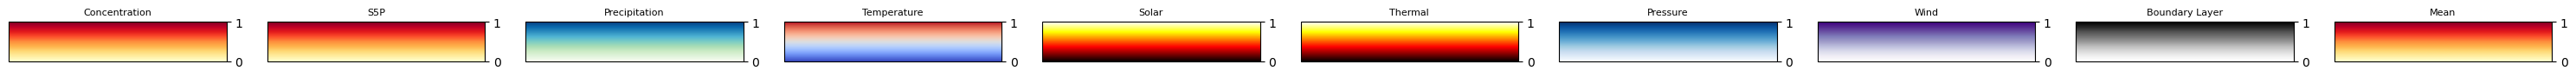

In [28]:
# Styled table with colour gradients per variable group.
summary_viz = summary.loc[:, ~summary.columns.duplicated()].copy()
summary_viz.columns.name = None
summary_viz = summary_viz.round(10)

for col in summary_viz.columns:
    try: summary_viz[col] = pd.to_numeric(summary_viz[col])
    except (ValueError, TypeError): pass

color_map_rules = {
    'Concentration':'YlOrRd', 'S5P':'YlOrRd', 'Precipitation':'GnBu',
    'Temperature':'coolwarm', 'Solar':'hot', 'Thermal':'hot',
    'Pressure':'Blues', 'Wind':'Purples', 'Boundary Layer':'Greys',
    'Mean':'YlOrRd',
}

def get_col_scale(series, buffer=0.05):
    vals = pd.to_numeric(series, errors='coerce').dropna()
    if len(vals) == 0: return None, None
    vmin, vmax = vals.min(), vals.max()
    diff = vmax - vmin
    return vmin - diff*buffer, vmax + diff*buffer

scales = {}
for c in summary_viz.select_dtypes(include=['float','int']).columns:
    vmin, vmax = get_col_scale(summary_viz[c])
    if vmin is not None: scales[c] = (vmin, vmax)

styled = summary_viz.style
for col in summary_viz.columns:
    cmap = next((cm for key, cm in color_map_rules.items() if key in col), None)
    if cmap and col in scales:
        vmin, vmax = scales[col]
        styled = styled.background_gradient(subset=[col], cmap=cmap, vmin=vmin, vmax=vmax)

styled = (styled
    .set_properties(**{'text-align':'center','font-family':'Segoe UI, sans-serif',
                       'font-size':'10pt','border':'1px solid #e0e0e0','padding':'4px 8px'})
    .format(precision=6))
display(styled)

# Colorbar legend
legend_data = {}
for key, cmap_name in color_map_rules.items():
    cols = [c for c in summary_viz.columns if key in c and c in scales]
    if cols:
        vmins = [scales[c][0] for c in cols if scales[c][0] is not None]
        vmaxs = [scales[c][1] for c in cols if scales[c][1] is not None]
        if vmins and vmaxs: legend_data[key] = (cmap_name, min(vmins), max(vmaxs))

if legend_data:
    fig, axes = plt.subplots(1, len(legend_data), figsize=(3*len(legend_data), 1))
    if len(legend_data) == 1: axes = [axes]
    for ax, (label, (cmap_name, vmin, vmax)) in zip(axes, legend_data.items()):
        if vmin is not None and vmax is not None and vmin != vmax:
            mpl.colorbar.ColorbarBase(ax, cmap=mpl.colormaps[cmap_name])
        ax.set_title(label, fontsize=8)
    plt.tight_layout()
    plt.show()

### Visualisation - Cleaned dataset (NaN and negatives removed)

> NaN values in the S5P column are expected and are kept here — only rows that are entirely NaN
> or have negative ground-level concentrations are removed.

  Cleaning summary:
    NaN rows removed: 0
    Rows removed for negative concentration: 0  (0 negative values)
    Final dataset: 10 rows x 24 columns
    Note: NaN values in the S5P column are expected and normal — Sentinel-5P did not have an image available for that day at that location.


,Date,Region,Station ID,Latitude,Longitude,Pollutant,"Previous Mean (NO2, µg/m³)","Current Mean (NO2, µg/m³)",S5P Concentration NO2 (mol/m2),S5P Date,Previous Temperature (°C),Current Temperature (°C),Previous Pressure (hPa),Current Pressure (hPa),Previous Precipitation (mm),Current Precipitation (mm),Previous Wind Speed (m/s),Current Wind Speed (m/s),Previous Solar Radiation (kJ/m²),Current Solar Radiation (kJ/m²),Previous Thermal Radiation (kJ/m²),Current Thermal Radiation (kJ/m²),Previous Boundary Layer (km),Current Boundary Layer (km)
0,2022-01-01,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,20.124637,26.459204,0.000123,2022-01-01,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
1,2022-01-01,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,12.118443,16.810966,0.000098,2022-01-01,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
2,2022-01-02,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,38.171632,31.485360,0.000120,2022-01-02,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
3,2022-01-02,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,26.937362,20.628821,nan,2022-01-02,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
4,2022-01-03,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,17.981429,29.818112,nan,2022-01-03,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
5,2022-01-03,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,20.624885,33.096787,nan,2022-01-03,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
6,2022-01-04,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,24.953334,39.326423,nan,2022-01-04,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
7,2022-01-04,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,15.300217,37.471306,nan,2022-01-04,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733
8,2022-01-05,EEA,Germany_Frankfurt Friedberger Landstraße_8.69191_50.12459,50.124590,8.691910,NO2,30.846828,nan,0.000072,2022-01-05,7.933801,8.190875,990.368512,990.064725,0.000375,0.000285,4.107547,4.176972,35.913498,226.537035,-89.527065,-104.806203,0.616109,0.724902
9,2022-01-05,EEA,Germany_Frankfurt Ost_8.74634_50.12533,50.125330,8.746340,NO2,23.868507,nan,0.000077,2022-01-05,8.015885,8.256966,991.783818,991.483736,0.000377,0.000297,4.139083,4.188178,35.940956,225.000384,-89.851729,-104.569732,0.617110,0.724733


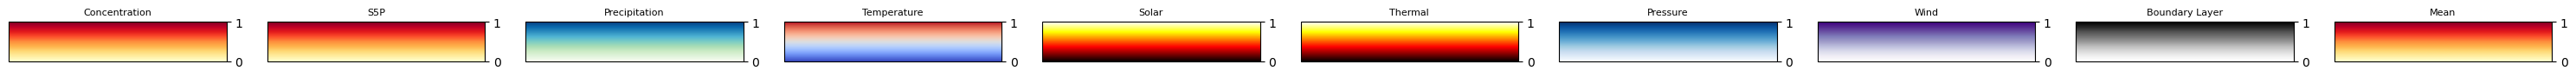

In [29]:
summary_clean = summary.loc[:, ~summary.columns.duplicated()].copy()
summary_clean.columns.name = None
summary_clean = summary_clean.replace(['None','none','NaN','nan',''], np.nan).round(10)

for col in summary_clean.columns:
    try: summary_clean[col] = pd.to_numeric(summary_clean[col])
    except (ValueError, TypeError): pass

n_before = len(summary_clean)
summary_clean = summary_clean.dropna(how='all').reset_index(drop=True)
n_nan_removed = n_before - len(summary_clean)

conc_cols = [c for c in summary_clean.columns if 'Concentration' in c or 'Mean' in c]
n_before2 = len(summary_clean)
if conc_cols:
    mask_neg = (summary_clean[conc_cols] < 0).any(axis=1)
    n_neg    = int(mask_neg.sum())
    summary_clean = summary_clean[~mask_neg].reset_index(drop=True)
else:
    n_neg = 0
n_neg_removed = n_before2 - len(summary_clean)

print('  Cleaning summary:')
print(f'    NaN rows removed: {n_nan_removed:,}')
print(f'    Rows removed for negative concentration: {n_neg_removed:,}  ({n_neg} negative values)')
print(f'    Final dataset: {len(summary_clean):,} rows x {len(summary_clean.columns)} columns')
print(f'    Note: NaN values in the S5P column are expected and normal — '
      f'Sentinel-5P did not have an image available for that day at that location.')

scales_c = {}
for c in summary_clean.select_dtypes(include=['float','int']).columns:
    vals = pd.to_numeric(summary_clean[c], errors='coerce').dropna()
    if len(vals):
        vmin, vmax = vals.min(), vals.max()
        diff = vmax - vmin
        scales_c[c] = (vmin - diff*0.05, vmax + diff*0.05)

styled_c = summary_clean.style
for col in summary_clean.columns:
    cmap = next((cm for key, cm in color_map_rules.items() if key in col), None)
    if cmap and col in scales_c:
        vmin, vmax = scales_c[col]
        styled_c = styled_c.background_gradient(subset=[col], cmap=cmap, vmin=vmin, vmax=vmax)

styled_c = (styled_c
    .set_properties(**{'text-align':'center','font-family':'Segoe UI, sans-serif',
                       'font-size':'10pt','border':'1px solid #e0e0e0','padding':'4px 8px'})
    .format(precision=6))
display(styled_c)

legend_c = {}
for key, cmap_name in color_map_rules.items():
    cols = [c for c in summary_clean.columns if key in c]
    if cols:
        num_vals = pd.to_numeric(summary_clean[cols].stack(), errors='coerce').dropna()
        if len(num_vals) == 0:
            continue
        vmin = float(num_vals.min())
        vmax = float(num_vals.max())
        if pd.notna(vmin) and pd.notna(vmax) and vmin != vmax:
            legend_c[key] = (cmap_name, vmin, vmax)

if legend_c:
    fig, axes = plt.subplots(1, len(legend_c), figsize=(3*len(legend_c), 1))
    if len(legend_c) == 1: axes = [axes]
    for ax, (label, (cmap_name, vmin, vmax)) in zip(axes, legend_c.items()):
        if pd.notna(vmin) and pd.notna(vmax) and vmin != vmax:
            mpl.colorbar.ColorbarBase(ax, cmap=mpl.colormaps[cmap_name])
        ax.set_title(label, fontsize=8)
    plt.tight_layout()
    plt.show()

### Step 11 - Concentration Time Series

Daily mean `curr_mean` and `prev_mean` per station over the analysis period.
This is useful for spotting trends, outliers, or data gaps before export.

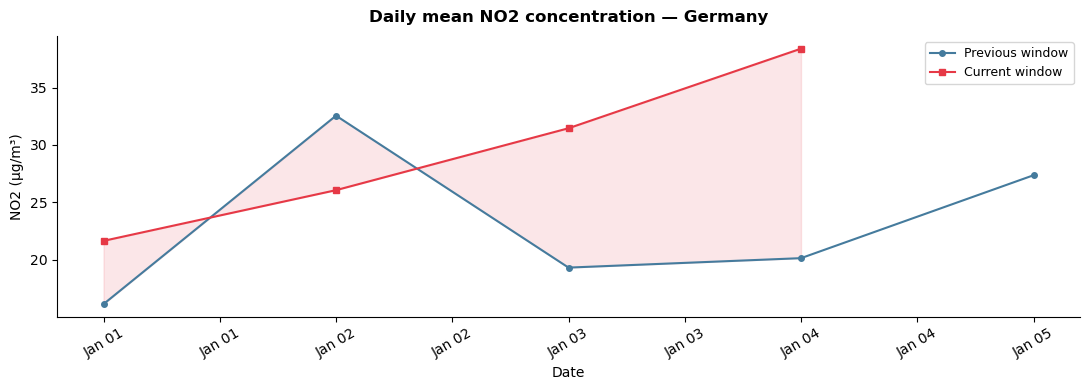

In [30]:
# Time series of ground-level concentration per station
conc_col_curr = f'Current Mean ({pollutant_symbol}, µg/m³)'
conc_col_prev = f'Previous Mean ({pollutant_symbol}, µg/m³)'

if conc_col_curr not in summary_clean.columns:
    print('Concentration columns not found — skipping time series plot.')
else:
    ts_data = summary_clean.copy()
    ts_data['Date'] = pd.to_datetime(ts_data['Date'])
    daily = ts_data.groupby('Date')[[conc_col_prev, conc_col_curr]].mean()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(daily.index, daily[conc_col_prev], label='Previous window',
            color='#457B9D', marker='o', markersize=4, linewidth=1.5)
    ax.plot(daily.index, daily[conc_col_curr], label='Current window',
            color='#E63946', marker='s', markersize=4, linewidth=1.5)
    ax.fill_between(daily.index, daily[conc_col_prev], daily[conc_col_curr],
                    alpha=0.12, color='#E63946')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(f'{pollutant_symbol} (µg/m³)', fontsize=10)
    ax.set_title(f'Daily mean {pollutant_symbol} concentration — {selection_label}',
                 fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%b %d'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Step 12 - Export Results

Saves the final cleaned dataset to a timestamped CSV inside a dedicated results folder.
The filename encodes the analysis period for easy identification.

In [ ]:
# Save the final cleaned dataset to a timestamped CSV.
W = 56

start_str  = pd.to_datetime(cfg['start_date']).strftime('%Y%m%d')
end_str    = pd.to_datetime(cfg['end_date']).strftime('%Y%m%d')
output_dir = f'results/EEA_ERA5_S5P_{start_str}_to_{end_str}'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'summary_clean.csv')
summary_clean.to_csv(output_path, index=False)

print('  Export complete')
print(f'  Rows exported  : {len(summary_clean):,}')
print(f'  Columns        : {len(summary_clean.columns)}')
print(f'  Saved to       : {output_path}')